# --- MySQL Connection Setup ---
To run our experiments, please update the MySQL connection settings in the following function to match your local database environment (host/port/user/password/database). After replacing these values, you should be able to connect to your MySQL server and execute all experiment scripts normally.


In [1]:

import json
import pathlib
import getpass
import mysql.connector
from mysql.connector import Error
import time
from itertools import chain, combinations, groupby
from prettytable import PrettyTable
import os
import csv
import itertools
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx


from scipy.optimize import curve_fit




def get_mysql_connection():
    return mysql.connector.connect(
        host="localhost",
        port=3306,
        user="root",             # ------- modify to your own user
        password="yzh_20010315", # ------- modify to your own password
        database="hockey",
    )


# test
try:
    conn = get_mysql_connection()
    if conn.is_connected():
        print("✔ MySQL connected successfully!")
except Error as e:
    print("Error:", e)
finally:
    if "conn" in locals() and conn.is_connected():
        conn.close()

✔ MySQL connected successfully!


# --- 10 tables ---

In [2]:
l1 = {
    'abbrev': ['Type', 'Code', 'Fullname'],
    'awardscoaches': ['coachID', 'award', 'year', 'lgID'],
    'awardsmisc': ['name', 'ID', 'award', 'year', 'lgID'],
    'awardsplayers': ['playerID', 'award', 'year', 'lgID', 'pos'],
    'coaches': ['coachID', 'year', 'tmID', 'lgID', 'stint'],
    'combinedshutouts': ['year', 'month', 'date', 'tmID', 'oppID', 'R/P', 'IDgoalie1', 'IDgoalie2'],
    'goalies': ['playerID', 'year', 'stint', 'tmID', 'lgID', 'GP'],
    'goaliessc': ['playerID', 'year', 'tmID', 'lgID', 'GP'],
    'goaliesshootout': ['playerID', 'year', 'stint', 'tmID'],
    'hof': ['year', 'hofID', 'name', 'category'],
    'master': ['playerID', 'coachID', 'hofID', 'legendsID', 'ihdbID', 'hrefID', 'lastName', 'nameGiven', 'birthYear', 'pos'],
    'scoring': ['playerID', 'year', 'stint', 'tmID', 'lgID', 'pos'],
    'scoringsc': ['playerID', 'year', 'tmID', 'lgID', 'pos'],
    'scoringshootout': ['playerID', 'year', 'stint', 'tmID'],
    'scoringsup': ['playerID', 'year'],
    'seriespost': ['year', 'round', 'series', 'tmIDWinner', 'lgIDWinner', 'tmIDLoser', 'lgIDLoser'],
    'teams': ['year', 'lgID', 'tmID', 'franchID', 'confID', 'divID', 'rank', 'name'],
    'teamshalf': ['year', 'lgID', 'tmID', 'half', 'rank'],
    'teamsplits': ['year', 'lgID', 'tmID'],
    'teamspost': ['year', 'lgID', 'tmID'],
    'teamssc': ['year', 'lgID', 'tmID'],
    'teamvsteam': ['year', 'lgID', 'tmID', 'oppID']
}


total_table = PrettyTable()
total_table.field_names = ['Table Name', 'Columns']


for key, values in l1.items():
    col = ', '.join(v for v in values)
    total_table.add_row([key, col])
    
# print(total_table)


# --- Method ---
### Calculate max/min uniqueness ratio, running time and completeness ratio

In [3]:
def get_column_names(cursor, table_name):
    """Get all column names of a database table"""
    cursor.execute(f"DESCRIBE `{table_name}`")
    return [column[0] for column in cursor.fetchall()]


# Uniqueness Ratio
def pmax_uniqueness_ratio_sql(cursor, table_name, columns):
    """Calculates the Uniqueness Ratio for a given column permutation"""
    if not columns:
        return 0, 0
    columns_list = ', '.join([f"`{col}`" for col in columns])
    query = f"""
        SELECT
            ((null_rows + unique_rows) / total_rows) AS uniqueness_ratio
        FROM (
            SELECT
                (SELECT COUNT(*) FROM `{table_name}` WHERE {' OR '.join([f"`{col}` IS NULL" for col in columns])}) AS null_rows,
                (
                    SELECT COUNT(*)
                    FROM (
                        SELECT {columns_list}
                        FROM `{table_name}`
                        WHERE {' AND '.join([f"`{col}` IS NOT NULL" for col in columns])}
                        GROUP BY {columns_list}
                        HAVING COUNT(*) = 1
                    ) AS unique_data
                ) AS unique_rows,
                (SELECT COUNT(*) FROM {table_name}) AS total_rows
        ) AS results;
    """
    start_time = time.time()
    cursor.execute(query)
    result = cursor.fetchone()
    execution_time = time.time() - start_time
    ratio = result[0] if result else 0

    return float(ratio), float(execution_time)


def pmin_uniqueness_ratio(cursor, table_name, columns):

    columns_list = ', '.join([f"`{col}`" for col in columns])
    null_conditions = " OR ".join([f"{col} IS NULL" for col in columns])
    not_null_conditions = " AND ".join([f"{col} IS NOT NULL" for col in columns])
    insert_condition = ", ".join([f"NOTNULL_{col}" for col in columns])
    insert_condition1 = ", ".join([f"NULL_{col}" for col in columns])
    weak_similarity_condition = " AND ".join([f"(NOTNULL_{col} = NULL_{col} OR NOTNULL_{col} IS NULL OR NULL_{col} IS NULL)" for col in columns])
    checkin_condition = " AND ".join([f"({col} = NOTNULL_{col} OR ({col} IS NULL AND NOTNULL_{col} IS NULL))"for col in columns])
    declare_NOTNULL = '\n'.join([f"DECLARE NOTNULL_{col} VARCHAR(100);" for col in columns])
    declare_NULL = '\n'.join([f"DECLARE NULL_{col} VARCHAR(100);" for col in columns])

    cursor.execute("DROP PROCEDURE IF EXISTS possible_min;")
    cursor.execute("DROP TABLE IF EXISTS not_null_table;")
    cursor.execute("DROP TABLE IF EXISTS include_null_table;")
    cursor.execute(f"CREATE TABLE not_null_table AS SELECT {columns_list} FROM {table_name} WHERE {not_null_conditions};")
    cursor.execute(f"CREATE TABLE include_null_table AS SELECT {columns_list} FROM {table_name} WHERE {null_conditions};")

    query1 = f"""
        CREATE PROCEDURE possible_min()
        BEGIN
            DECLARE total_count INT DEFAULT 0;
            DECLARE unique_count INT DEFAULT 0;
            DECLARE FLAG INT;
            DECLARE done INT DEFAULT FALSE;
            {declare_NOTNULL}
            {declare_NULL}
            DECLARE cur_null CURSOR FOR SELECT * FROM include_null_table;
            DECLARE cur_not_null CURSOR FOR SELECT * FROM not_null_table;
            DECLARE CONTINUE HANDLER FOR NOT FOUND SET done = TRUE;

            DROP TEMPORARY TABLE IF EXISTS weak_similar_table;
            CREATE TEMPORARY TABLE weak_similar_table LIKE not_null_table;

            OPEN cur_null;
                outer_loop: LOOP
                    FETCH cur_null INTO {insert_condition1};
                    IF done THEN
                        LEAVE outer_loop;
                    END IF;
                    SET FLAG = 1;
                    OPEN cur_not_null;
                        inner_loop: LOOP
                            FETCH cur_not_null INTO {insert_condition};
                            IF done THEN
                                SET done = FALSE;
                                LEAVE inner_loop;
                            END IF;
                            IF ({weak_similarity_condition}) THEN
                                IF NOT EXISTS(SELECT 1 FROM weak_similar_table WHERE ({checkin_condition})) THEN
                                    INSERT INTO weak_similar_table VALUES ({insert_condition});
                                    SET FLAG = 0;
                                    SET done = FALSE;
                                    LEAVE inner_loop;
                                END IF;
                            END IF;
                        END LOOP inner_loop;
                    CLOSE cur_not_null;
                    IF FLAG = 1 THEN
                        INSERT INTO not_null_table VALUES ({insert_condition1});
                    END IF;
                END LOOP outer_loop;
            CLOSE cur_null;
            INSERT INTO weak_similar_table ({columns_list}) SELECT {columns_list} FROM not_null_table;
        END;
    """

    final_query = f"""
        SELECT
            (SELECT COUNT(*) FROM (
                SELECT COUNT(*) AS cnt
                FROM weak_similar_table
                GROUP BY {columns_list}
                HAVING COUNT(*) = 1
            ) AS unique_counts) /
            (SELECT COUNT(*) FROM {table_name}) AS ratio;
    """
    t0 = time.time()
    cursor.execute(query1)
    cursor.execute(f"CALL possible_min();")
    cursor.execute(final_query)
    row = cursor.fetchone()          # (0.12345,)
    ratio = row[0] if row and row[0] is not None else 0.0
    t = time.time() - t0
    return float(ratio), float(t)



# Completeness Ratio
def completeness_ratio(cursor, table_name, columns):
    if not columns:
        return 0

    cursor.execute(f"SELECT COUNT(*) FROM `{table_name}`;")
    total_counts = cursor.fetchone()[0]

    query = " AND ".join([f"`{col}` IS NOT NULL" for col in columns])
    cursor.execute(f"SELECT COUNT(*) FROM `{table_name}` WHERE {query};")
    non_null_count = cursor.fetchone()[0]

    cr = non_null_count/total_counts
    return float(cr)


# Show All Ratios in Tables

In [4]:
def ensure_dir(folder_name: str):
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)


def build_output_csv_path(table_name: str, folder_name: str = "ur_result"):
    ensure_dir(folder_name)
    filename = f"{table_name}_result.csv"
    return os.path.join(folder_name, filename)


def main_ur(table_name, columns):
    connection = None
    cursor = None

    try:
        connection = get_mysql_connection()
        cursor = connection.cursor()

        all_combinations = [
            combo
            for length in range(1, len(columns) + 1)
            for combo in combinations(columns, length)
        ]

        detailed_output = []

        # 逐个组合计算 max/min/CR + time
        for perm in all_combinations:
            # ---- max (pmax) ----
            max_ratio, max_time = pmax_uniqueness_ratio_sql(cursor, table_name, perm)

            # ---- min (pmin) ----
            if table_name == "aa":
                min_ratio, min_time = pmin_uniqueness_ratio(cursor, table_name, perm)
            else:
                min_ratio, min_time = 0.000, 0.000

            # ---- CR ----
            cr = completeness_ratio(cursor, table_name, perm)

            detailed_output.append((perm, max_ratio, max_time, min_ratio, min_time, cr))

        # ------------------------
        # Print PrettyTable
        # ------------------------
        table = PrettyTable()
        table.field_names = ["Key", "max_ratio", "max_time", "min_ratio", "min_time", "CR"]

        for perm, max_ratio, max_time, min_ratio, min_time, cr in detailed_output:
            table.add_row([
                ", ".join(perm),
                f"{max_ratio:.4f}",
                f"{max_time:.4f}",
                f"{min_ratio:.4f}",
                f"{min_time:.4f}",
                f"{cr:.4f}",
            ])

        print(table)

        # ------------------------
        # Export CSV
        # ------------------------
        output_csv_path = build_output_csv_path(table_name)

        headers = ["table_name", "key", "max", "max_time", "min", "min_time", "CR"]

        with open(output_csv_path, mode="w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow(headers)

            for perm, max_ratio, max_time, min_ratio, min_time, cr in detailed_output:
                writer.writerow([
                    table_name,
                    ", ".join(perm),
                    max_ratio,
                    max_time,
                    min_ratio,
                    min_time,
                    cr,
                ])

        print(f"\n[OK] CSV saved to: {output_csv_path}")

    except Error as e:
        print("Error:", e)

    finally:
        if cursor is not None:
            cursor.close()
        if connection is not None and connection.is_connected():
            connection.close()

for key, values in l1.items():
    print(f"Table: {key}\nColumns: {values}")
    main_ur(
        table_name=key,
        columns=values
    )


Table: abbrev
Columns: ['Type', 'Code', 'Fullname']
+----------------------+-----------+----------+-----------+----------+--------+
|         Key          | max_ratio | max_time | min_ratio | min_time |   CR   |
+----------------------+-----------+----------+-----------+----------+--------+
|         Type         |   0.0000  |  0.0019  |   0.0000  |  0.0000  | 1.0000 |
|         Code         |   0.6552  |  0.0006  |   0.0000  |  0.0000  | 1.0000 |
|       Fullname       |   1.0000  |  0.0006  |   0.0000  |  0.0000  | 1.0000 |
|      Type, Code      |   1.0000  |  0.0004  |   0.0000  |  0.0000  | 1.0000 |
|    Type, Fullname    |   1.0000  |  0.0005  |   0.0000  |  0.0000  | 1.0000 |
|    Code, Fullname    |   1.0000  |  0.0005  |   0.0000  |  0.0000  | 1.0000 |
| Type, Code, Fullname |   1.0000  |  0.0006  |   0.0000  |  0.0000  | 1.0000 |
+----------------------+-----------+----------+-----------+----------+--------+

[OK] CSV saved to: ur_result/abbrev_result.csv
Table: awardscoaches

# --- Box plot ---


[INFO] Plotting table: abbrev  (file=abbrev_result.csv)


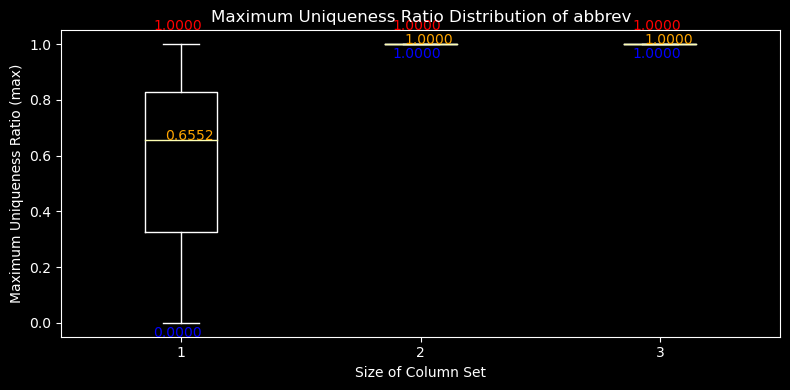


[INFO] Plotting table: awardscoaches  (file=awardscoaches_result.csv)


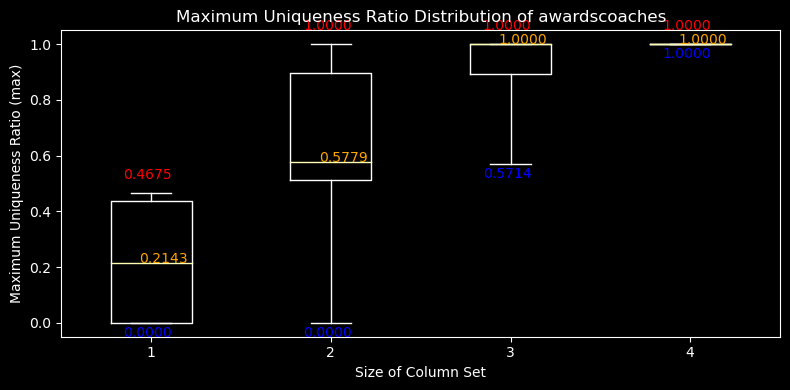


[INFO] Plotting table: awardsmisc  (file=awardsmisc_result.csv)


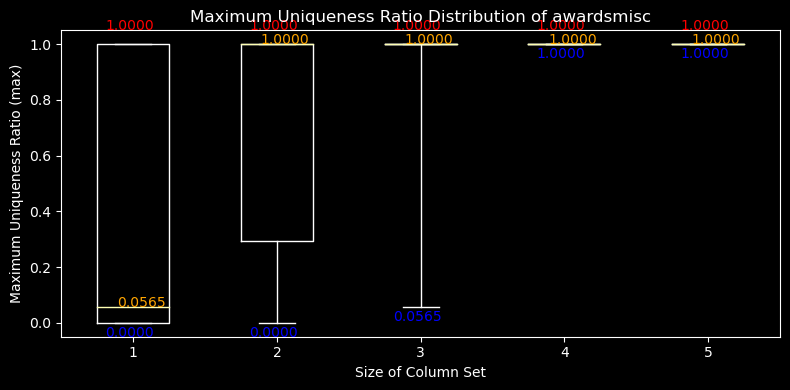


[INFO] Plotting table: awardsplayers  (file=awardsplayers_result.csv)


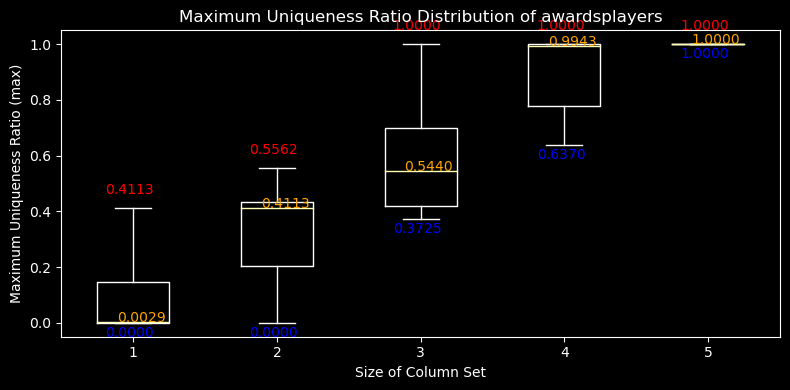


[INFO] Plotting table: coaches  (file=coaches_result.csv)


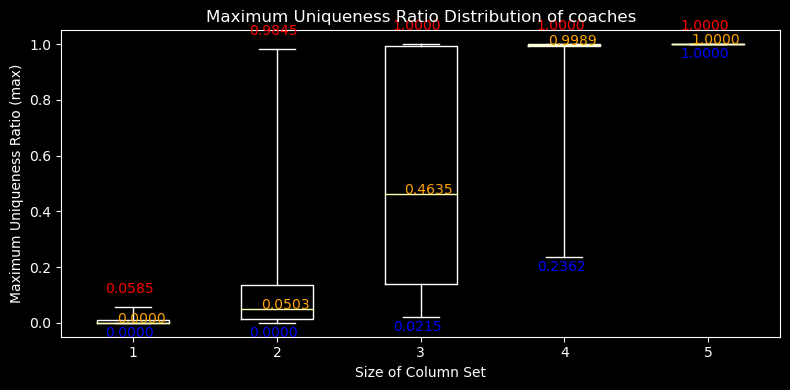


[INFO] Plotting table: combinedshutouts  (file=combinedshutouts_result.csv)


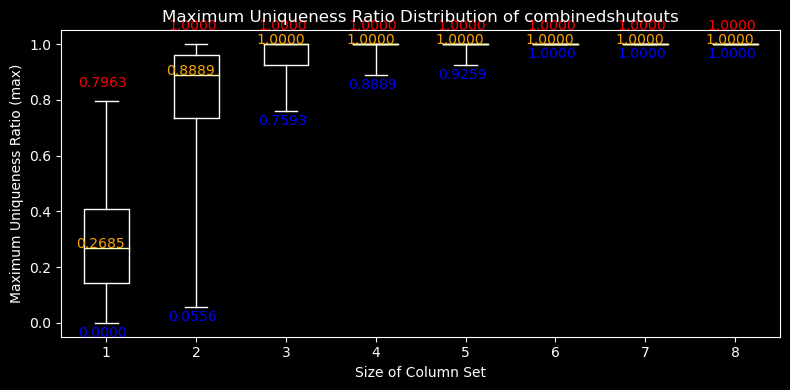


[INFO] Plotting table: goalies  (file=goalies_result.csv)


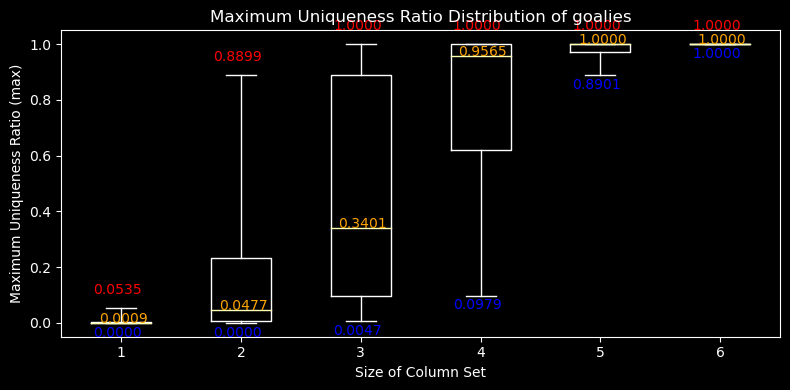


[INFO] Plotting table: goaliessc  (file=goaliessc_result.csv)


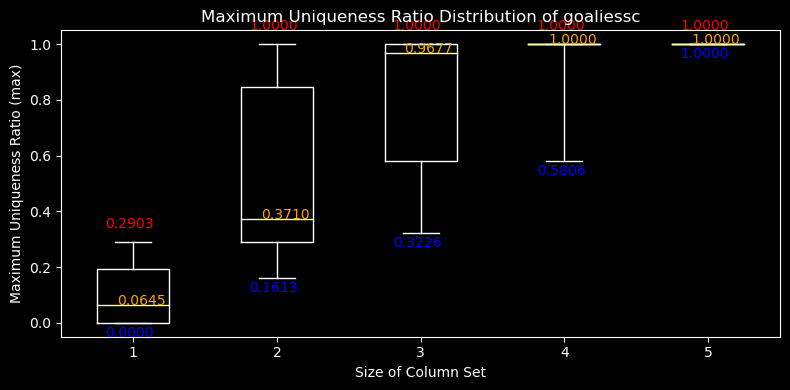


[INFO] Plotting table: goaliesshootout  (file=goaliesshootout_result.csv)


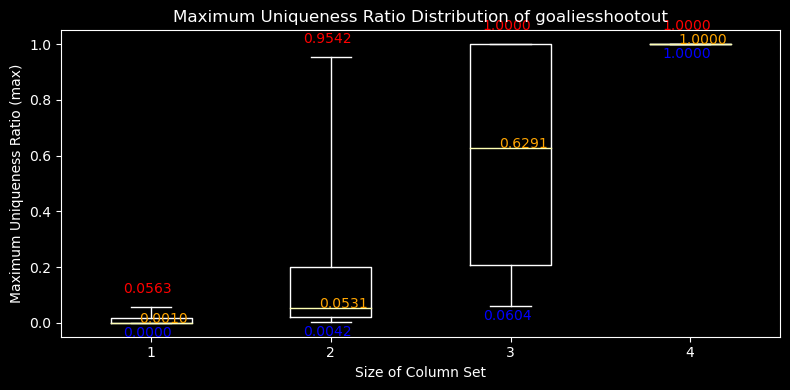


[INFO] Plotting table: hof  (file=hof_result.csv)


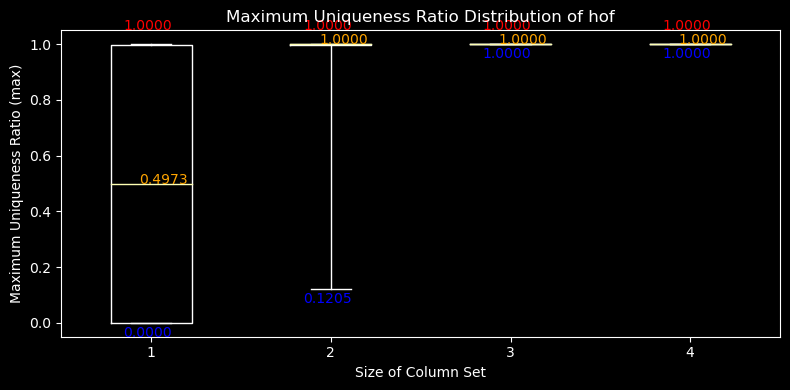


[INFO] Plotting table: master  (file=master_result.csv)


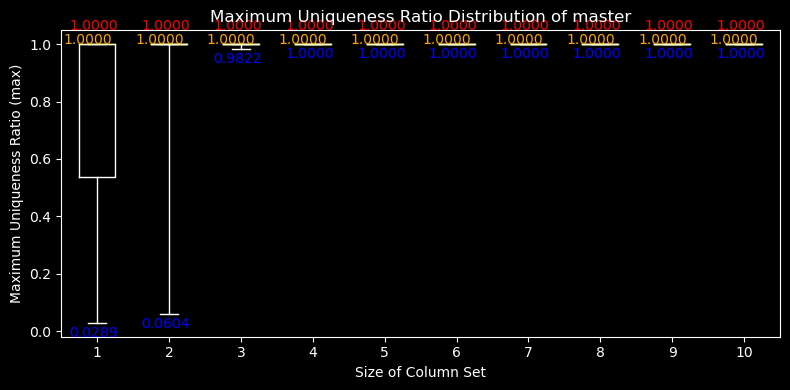


[INFO] Plotting table: scoring  (file=scoring_result.csv)


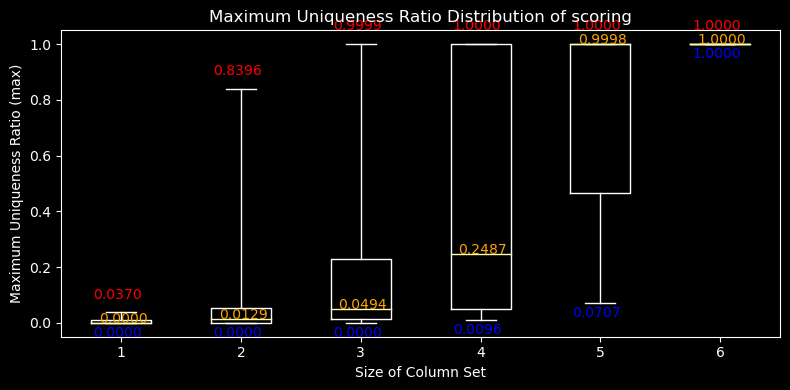


[INFO] Plotting table: scoringsc  (file=scoringsc_result.csv)


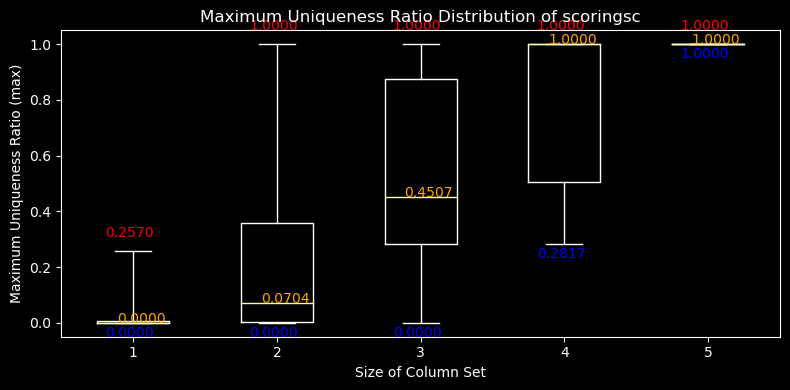


[INFO] Plotting table: scoringshootout  (file=scoringshootout_result.csv)


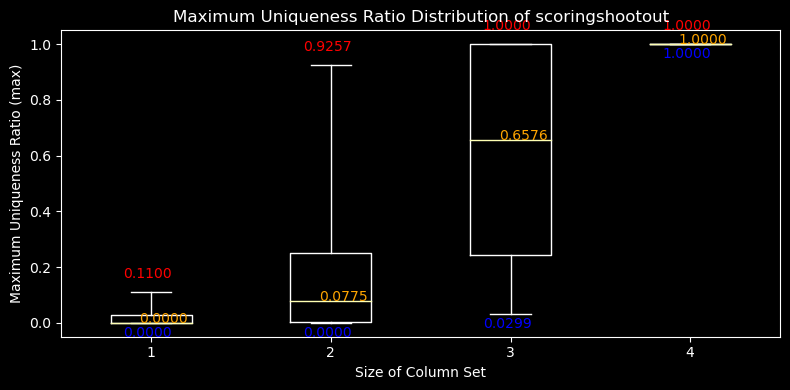


[INFO] Plotting table: scoringsup  (file=scoringsup_result.csv)


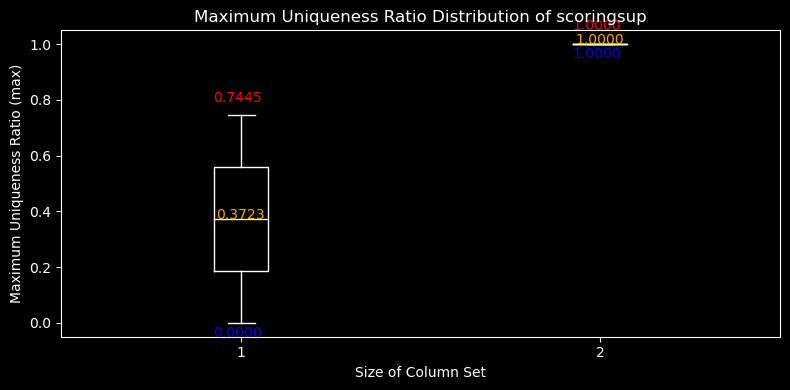


[INFO] Plotting table: seriespost  (file=seriespost_result.csv)


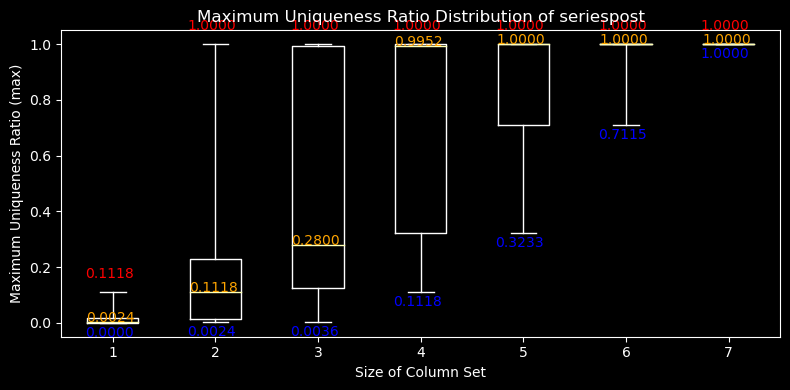


[INFO] Plotting table: teams  (file=teams_result.csv)


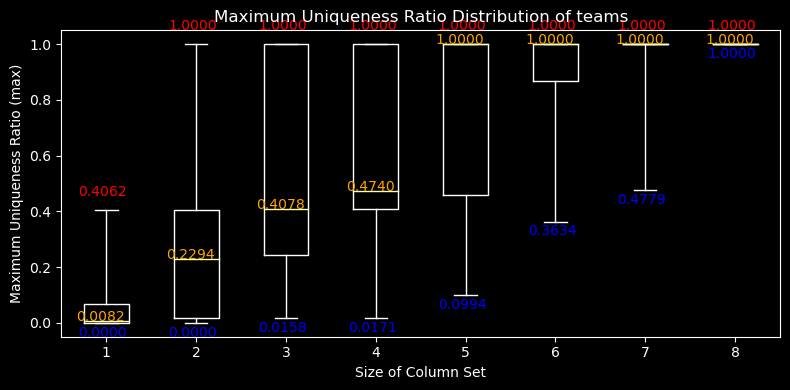


[INFO] Plotting table: teamshalf  (file=teamshalf_result.csv)


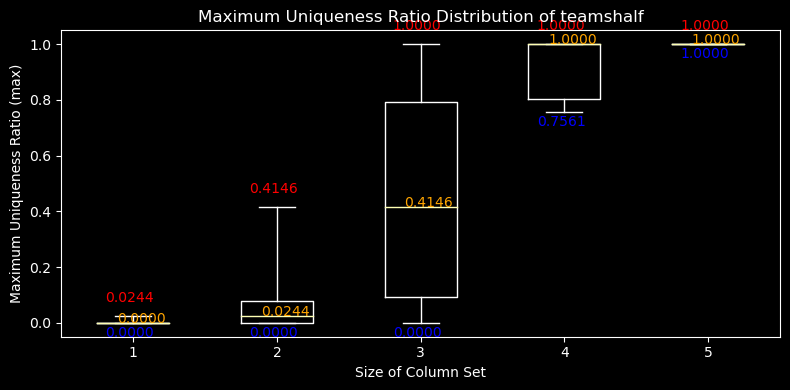


[INFO] Plotting table: teamsplits  (file=teamsplits_result.csv)


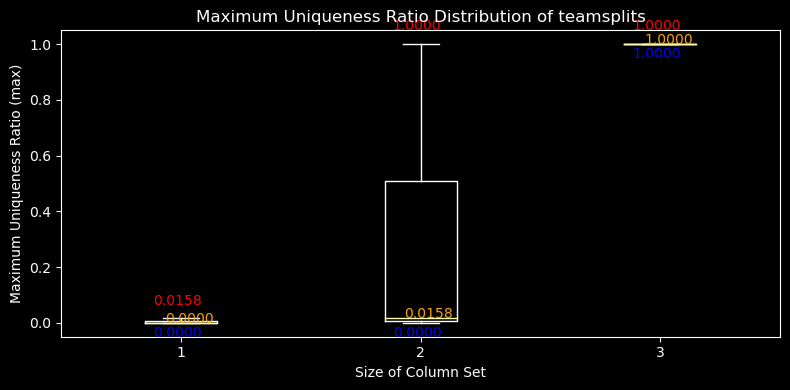


[INFO] Plotting table: teamspost  (file=teamspost_result.csv)


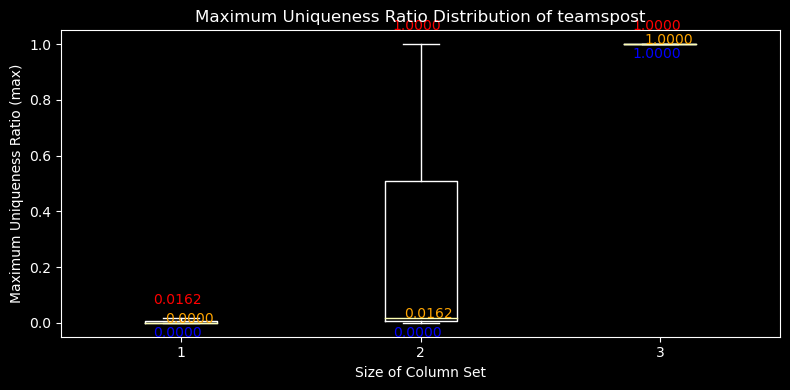


[INFO] Plotting table: teamssc  (file=teamssc_result.csv)


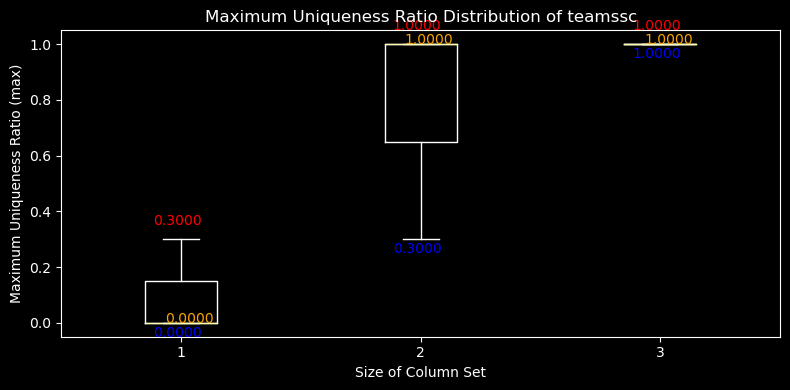


[INFO] Plotting table: teamvsteam  (file=teamvsteam_result.csv)


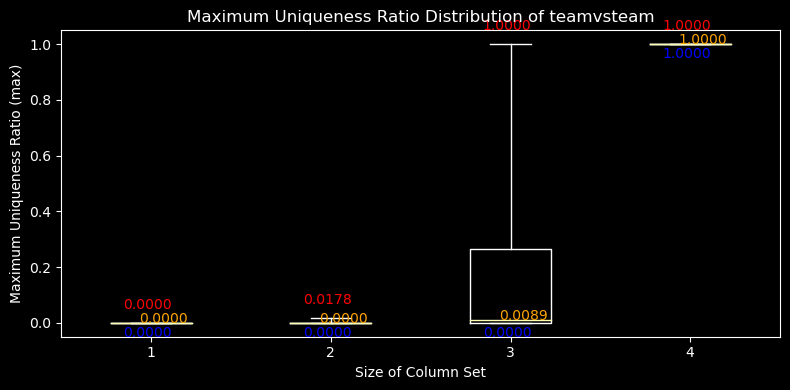

In [5]:

# ----------------------------
# Helper: count key length
# ----------------------------
def get_key_length(key_str: str) -> int:
    """
    key_str example:
      "Type, Code"
      "playerID"
    """
    if key_str is None:
        return 0
    key_str = key_str.strip()
    if not key_str:
        return 0
    return len([x.strip() for x in key_str.split(",") if x.strip()])


# ----------------------------
# Read one table csv result
# ----------------------------
def read_ur_result_csv(csv_path: str):
    """
    Expect headers:
      table_name, key, max, max_time, min, min_time, CR
    Return:
      dict: {length: [max_values]}
    """
    max_by_length = {}

    with open(csv_path, mode="r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)

        for row in reader:
            key_str = row.get("key")
            max_str = row.get("max")

            if key_str is None or max_str is None:
                continue

            try:
                key_len = get_key_length(key_str)
                max_val = float(max_str)
            except Exception:
                continue

            if key_len not in max_by_length:
                max_by_length[key_len] = []
            max_by_length[key_len].append(max_val)

    return max_by_length


# ----------------------------
# Plot boxplot for one table
# ----------------------------
def plot_box_for_table(table_name: str, max_by_length: dict):
    if not max_by_length:
        print(f"[SKIP] No data for table: {table_name}")
        return

    lengths = sorted(max_by_length.keys())
    ratio_lists = [max_by_length[l] for l in lengths]

    fig, ax = plt.subplots(figsize=(8, 4))
    box = ax.boxplot(
        ratio_lists,
        labels=[str(length) for length in lengths],
        whis=[0, 100],
        showfliers=True,
    )

    ax.set_xlabel("Size of Column Set")
    ax.set_ylabel("Maximum Uniqueness Ratio (max)")
    ax.set_title(f"Maximum Uniqueness Ratio Distribution of {table_name}")

    # --- annotate whiskers (min/max) ---
    for i, line in enumerate(box["whiskers"]):
        x, y = line.get_xydata()[1]
        if i % 2 == 0:
            ax.annotate(
                f"{y:.4f}",
                xy=(x, y),
                xytext=(-20, -10),
                textcoords="offset points",
                ha="left",
                va="baseline",
                color="blue",
                fontsize=10,
            )
        else:
            ax.annotate(
                f"{y:.4f}",
                xy=(x, y),
                xytext=(-20, 10),
                textcoords="offset points",
                ha="left",
                va="baseline",
                color="red",
                fontsize=10,
            )

    # --- annotate medians ---
    for i, line in enumerate(box["medians"]):
        x, y = line.get_xydata()[1]
        ax.annotate(
            f"{y:.4f}",
            xy=(x, y),
            xytext=(-20, 0),
            textcoords="offset points",
            ha="center",
            va="baseline",
            color="orange",
            fontsize=10,
        )

    plt.tight_layout()
    plt.show()


# ----------------------------
# Main: read all files in ur_result
# ----------------------------
def plot_all_tables_from_folder(folder="ur_result"):
    if not os.path.exists(folder):
        print(f"[ERROR] Folder not found: {folder}")
        return

    csv_files = [f for f in os.listdir(folder) if f.endswith(".csv")]
    if not csv_files:
        print(f"[ERROR] No .csv files found in folder: {folder}")
        return

    csv_files.sort()

    for filename in csv_files:
        csv_path = os.path.join(folder, filename)

        # infer table name from filename like "master_result.csv"
        table_name = filename.replace("_result.csv", "")

        print(f"\n[INFO] Plotting table: {table_name}  (file={filename})")

        max_by_length = read_ur_result_csv(csv_path)
        plot_box_for_table(table_name, max_by_length)


# ----------------------------
# Run
# ----------------------------
plot_all_tables_from_folder("ur_result")


# Top-5 keys table

In [6]:



def top_5_keys_from_csv(table_name, folder_name="ur_result", threshold = 0.95):
    """
    Read ur_result/{table_name}_result.csv and print:
      - Top-5 keys per key length level (by max desc, with excluded-elements logic)
      - Near-Keys (max > 0.95)

    CSV columns required:
      key, max, max_time, CR
    """

    csv_path = os.path.join(folder_name, f"{table_name}_result.csv")

    # ----------------------------
    # 1) Load CSV -> detailed_output[level] = [(perm, ur, cr, exec_time)]
    # ----------------------------
    detailed_output = {}

    with open(csv_path, mode="r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)

        for row in reader:
            perm = tuple(x.strip() for x in row["key"].split(",") if x.strip())
            ur = float(row["max"])
            cr = float(row["CR"])
            exec_time = float(row["max_time"])

            level = len(perm)
            if level not in detailed_output:
                detailed_output[level] = []
            detailed_output[level].append((perm, ur, cr, exec_time))

    # ----------------------------
    # 2) Helper: get_subkeys
    # ----------------------------
    def get_subkeys(key_tuple):
        return set(chain.from_iterable(combinations(key_tuple, r) for r in range(1, len(key_tuple) + 1)))

    # ----------------------------
    # 3) Top-5 + Near-key logic
    # ----------------------------
    excluded_elements = set()
    nk = []

    for level in sorted(detailed_output.keys()):
        entries = sorted(detailed_output[level], key=lambda x: x[1], reverse=True)

        top_five_ratios = sorted(set([e[1] for e in entries]), reverse=True)[:5]

        filtered_entries = []
        for perm, ur, cr, exec_time in entries:
            if ur not in top_five_ratios:
                continue
            if get_subkeys(perm).intersection(excluded_elements):
                continue
            filtered_entries.append((perm, ur, cr, exec_time))

        for perm, ur, cr, exec_time in filtered_entries:
            if ur == 1.0:
                excluded_elements.add(perm)
            if ur > threshold:
                nk.append([perm, ur, cr])

        # print Top-5 for this level
        if filtered_entries:
            print(f"Column Count: {level}")
            table = PrettyTable()
            table.field_names = ["Top-5 Keys", "UR(max)", "CR", "Time(max_time)"]

            for perm, ur, cr, exec_time in filtered_entries:
                table.add_row([
                    ", ".join(perm),
                    f"{ur:.4f}",
                    f"{cr:.4f}",
                    f"{exec_time:.4f}",
                ])

            print(table)
            print()

    # ---- save near key to folder
    nk_folder_name="near_key"
    os.makedirs(folder_name, exist_ok=True)

    out_path = os.path.join(folder_name, "near_key_all.csv")

    with open(out_path, mode="w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["table_name", "key", "UR(max)", "CR"])

        for table_name, values in nk_dic.items():
            for combo, ur, cr in values:
                writer.writerow([
                    table_name,
                    ", ".join(combo),
                    float(ur),
                    float(cr),
                ])

    print(f"[OK] near-keys saved to: {out_path}")


    # print Near-Keys
    print(f"Near-Keys (UR > {threshold}):")
    table2 = PrettyTable()
    table2.field_names = ["Keys", "UR(max)", "CR"]

    for perm, ur, cr in nk:
        table2.add_row([", ".join(perm), f"{ur:.4f}", f"{cr:.4f}"])

    print(table2)



    return nk


# ----------------------------
# Run all tables in l1
# ----------------------------
nk_dic = {}

for table_name in l1.keys():
    print("------------------------------------------------------------")
    print(f"Table: {table_name}")

    nk_dic[table_name] = top_5_keys_from_csv(table_name, folder_name="ur_result", threshold = 0.95)

print("\nDone! nk_dic is ready.")


------------------------------------------------------------
Table: abbrev
Column Count: 1
+------------+---------+--------+----------------+
| Top-5 Keys | UR(max) |   CR   | Time(max_time) |
+------------+---------+--------+----------------+
|  Fullname  |  1.0000 | 1.0000 |     0.0006     |
|    Code    |  0.6552 | 1.0000 |     0.0006     |
|    Type    |  0.0000 | 1.0000 |     0.0019     |
+------------+---------+--------+----------------+

Column Count: 2
+------------+---------+--------+----------------+
| Top-5 Keys | UR(max) |   CR   | Time(max_time) |
+------------+---------+--------+----------------+
| Type, Code |  1.0000 | 1.0000 |     0.0004     |
+------------+---------+--------+----------------+

[OK] near-keys saved to: ur_result/near_key_all.csv
Near-Keys (UR > 0.95):
+------------+---------+--------+
|    Keys    | UR(max) |   CR   |
+------------+---------+--------+
|  Fullname  |  1.0000 | 1.0000 |
| Type, Code |  1.0000 | 1.0000 |
+------------+---------+--------+


# Degree of violation distribution

[OK] loaded 103 near-keys from: ur_result/near_key_all.csv

==================== Table: awardsplayers; Near-key: ('playerID', 'year', 'pos') ====================



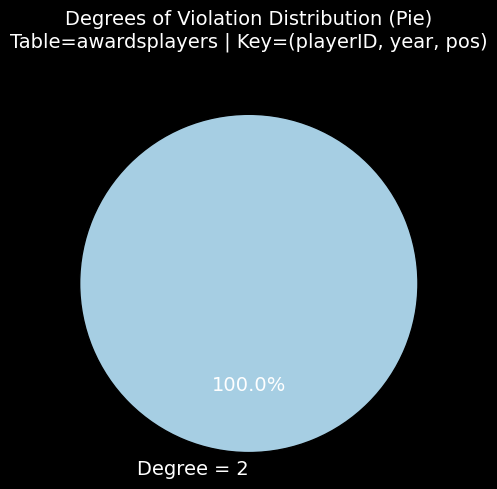


--- Table=awardsplayers | Key=(playerID, year, pos) | Degree=2 | Rows=6 ---
+---+-----------+------+-----+-------------+
| # |  playerID | year | pos | group_count |
+---+-----------+------+-----+-------------+
| 1 | barrato01 | 1983 |  G  |      2      |
| 2 | belfoed01 | 1990 |  G  |      2      |
| 3 | hextaro01 | 1986 |  G  |      2      |
| 4 | masonst01 | 2008 |  G  |      2      |
| 5 | robitlu01 | 1986 |  LW |      2      |
| 6 | selante01 | 1992 |  RW |      2      |
+---+-----------+------+-----+-------------+

==================== Table: awardsplayers; Near-key: ('playerID', 'year', 'lgID', 'pos') ====================



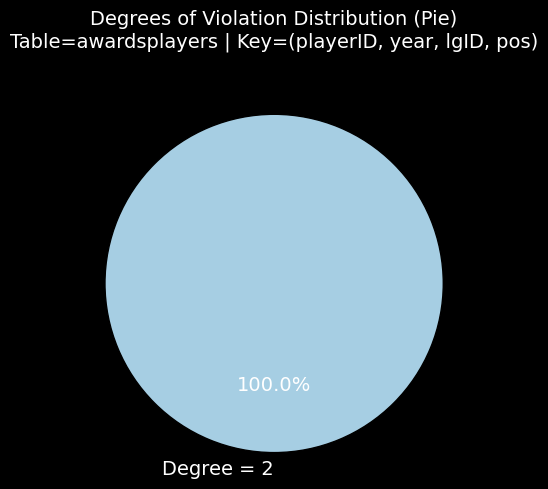


--- Table=awardsplayers | Key=(playerID, year, lgID, pos) | Degree=2 | Rows=6 ---
+---+-----------+------+------+-----+-------------+
| # |  playerID | year | lgID | pos | group_count |
+---+-----------+------+------+-----+-------------+
| 1 | barrato01 | 1983 | NHL  |  G  |      2      |
| 2 | belfoed01 | 1990 | NHL  |  G  |      2      |
| 3 | hextaro01 | 1986 | NHL  |  G  |      2      |
| 4 | masonst01 | 2008 | NHL  |  G  |      2      |
| 5 | robitlu01 | 1986 | NHL  |  LW |      2      |
| 6 | selante01 | 1992 | NHL  |  RW |      2      |
+---+-----------+------+------+-----+-------------+

==================== Table: coaches; Near-key: ('coachID', 'year') ====================



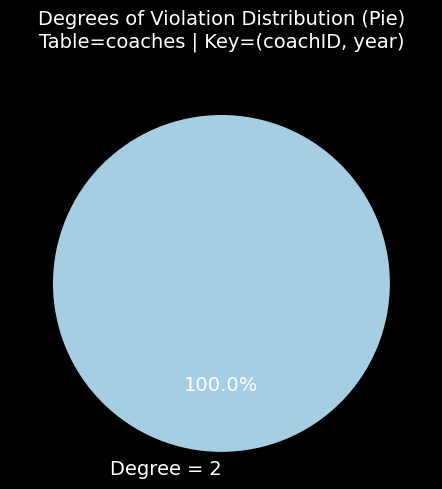


--- Table=coaches | Key=(coachID, year) | Degree=2 | Rows=14 ---
+----+------------+------+-------------+
| #  |  coachID   | year | group_count |
+----+------------+------+-------------+
| 1  | blairwr01c | 1968 |      2      |
| 2  | boudrbr01c | 2011 |      2      |
| 3  | bowmasc01c | 1981 |      2      |
| 4  | carlyra01c | 2011 |      2      |
| 5  | glovefr01c | 1971 |      2      |
| 6  | hartlbo01c | 2002 |      2      |
| 7  | hitchke01c | 2006 |      2      |
| 8  | martija02c | 2001 |      2      |
| 9  | nealeha01c | 1975 |      2      |
| 10 | neilsro01c | 1983 |      2      |
| 11 | nolante01c | 2007 |      2      |
| 12 | pilouru01c | 1974 |      2      |
| 13 | satorte01c | 1986 |      2      |
| 14 | sutteda01c | 2002 |      2      |
+----+------------+------+-------------+

==================== Table: coaches; Near-key: ('year', 'tmID', 'stint') ====================



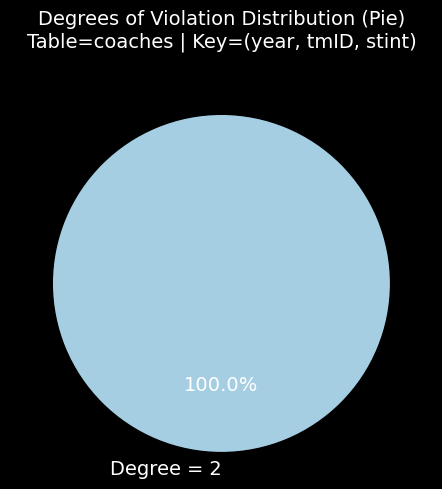


--- Table=coaches | Key=(year, tmID, stint) | Degree=2 | Rows=1 ---
+---+------+------+-------+-------------+
| # | year | tmID | stint | group_count |
+---+------+------+-------+-------------+
| 1 | 1998 | DET  |   1   |      2      |
+---+------+------+-------+-------------+

==================== Table: coaches; Near-key: ('coachID', 'year', 'tmID') ====================



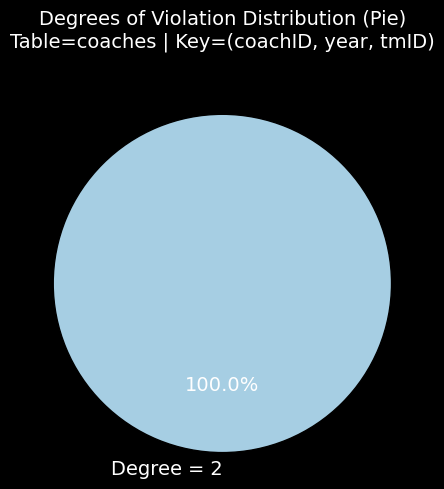


--- Table=coaches | Key=(coachID, year, tmID) | Degree=2 | Rows=5 ---
+---+------------+------+------+-------------+
| # |  coachID   | year | tmID | group_count |
+---+------------+------+------+-------------+
| 1 | blairwr01c | 1968 | MNS  |      2      |
| 2 | bowmasc01c | 1981 | BUF  |      2      |
| 3 | martija02c | 2001 | OTT  |      2      |
| 4 | nolante01c | 2007 | NYI  |      2      |
| 5 | pilouru01c | 1974 | WIJ  |      2      |
+---+------------+------+------+-------------+

==================== Table: coaches; Near-key: ('coachID', 'year', 'lgID') ====================



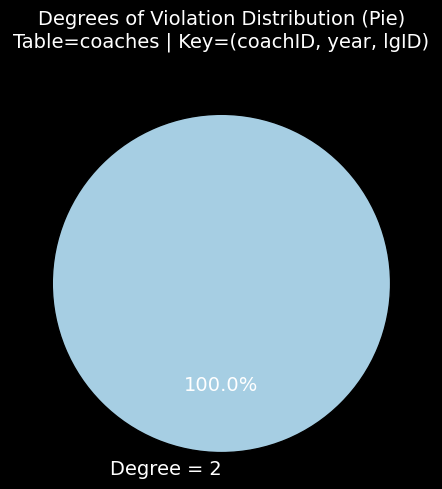


--- Table=coaches | Key=(coachID, year, lgID) | Degree=2 | Rows=14 ---
+----+------------+------+------+-------------+
| #  |  coachID   | year | lgID | group_count |
+----+------------+------+------+-------------+
| 1  | blairwr01c | 1968 | NHL  |      2      |
| 2  | boudrbr01c | 2011 | NHL  |      2      |
| 3  | bowmasc01c | 1981 | NHL  |      2      |
| 4  | carlyra01c | 2011 | NHL  |      2      |
| 5  | glovefr01c | 1971 | NHL  |      2      |
| 6  | hartlbo01c | 2002 | NHL  |      2      |
| 7  | hitchke01c | 2006 | NHL  |      2      |
| 8  | martija02c | 2001 | NHL  |      2      |
| 9  | nealeha01c | 1975 | WHA  |      2      |
| 10 | neilsro01c | 1983 | NHL  |      2      |
| 11 | nolante01c | 2007 | NHL  |      2      |
| 12 | pilouru01c | 1974 | WHA  |      2      |
| 13 | satorte01c | 1986 | NHL  |      2      |
| 14 | sutteda01c | 2002 | NHL  |      2      |
+----+------------+------+------+-------------+

==================== Table: coaches; Near-key: ('year', 'tmID',

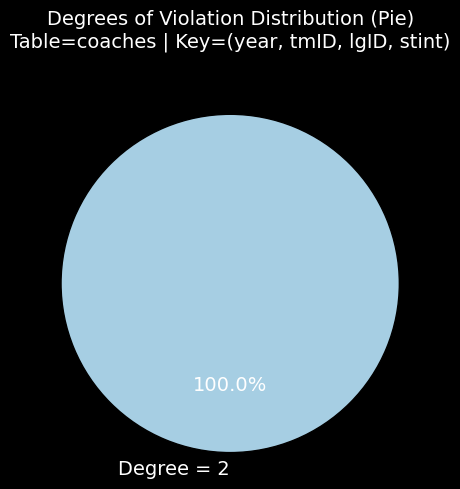


--- Table=coaches | Key=(year, tmID, lgID, stint) | Degree=2 | Rows=1 ---
+---+------+------+------+-------+-------------+
| # | year | tmID | lgID | stint | group_count |
+---+------+------+------+-------+-------------+
| 1 | 1998 | DET  | NHL  |   1   |      2      |
+---+------+------+------+-------+-------------+

==================== Table: coaches; Near-key: ('coachID', 'year', 'tmID', 'lgID') ====================



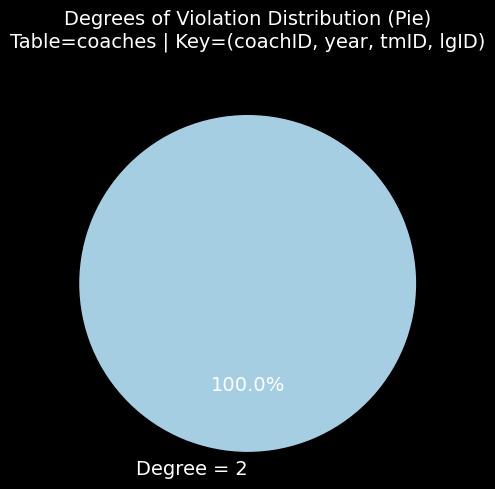


--- Table=coaches | Key=(coachID, year, tmID, lgID) | Degree=2 | Rows=5 ---
+---+------------+------+------+------+-------------+
| # |  coachID   | year | tmID | lgID | group_count |
+---+------------+------+------+------+-------------+
| 1 | blairwr01c | 1968 | MNS  | NHL  |      2      |
| 2 | bowmasc01c | 1981 | BUF  | NHL  |      2      |
| 3 | martija02c | 2001 | OTT  | NHL  |      2      |
| 4 | nolante01c | 2007 | NYI  | NHL  |      2      |
| 5 | pilouru01c | 1974 | WIJ  | WHA  |      2      |
+---+------------+------+------+------+-------------+

==================== Table: combinedshutouts; Near-key: ('month', 'IDgoalie1') ====================



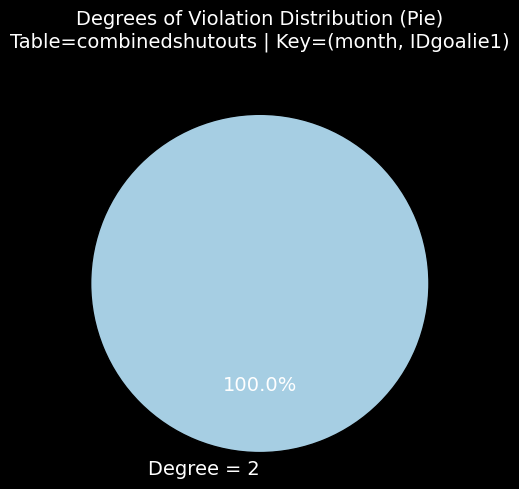


--- Table=combinedshutouts | Key=(month, IDgoalie1) | Degree=2 | Rows=1 ---
+---+-------+-----------+-------------+
| # | month | IDgoalie1 | group_count |
+---+-------+-----------+-------------+
| 1 |   3   | plantja01 |      2      |
+---+-------+-----------+-------------+

==================== Table: combinedshutouts; Near-key: ('month', 'IDgoalie2') ====================



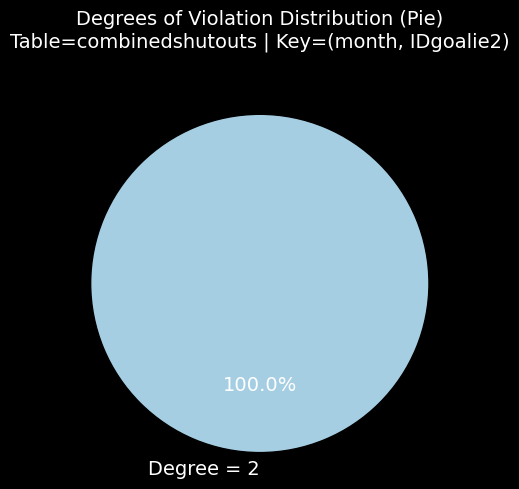


--- Table=combinedshutouts | Key=(month, IDgoalie2) | Degree=2 | Rows=1 ---
+---+-------+-----------+-------------+
| # | month | IDgoalie2 | group_count |
+---+-------+-----------+-------------+
| 1 |   10  | legacma01 |      2      |
+---+-------+-----------+-------------+

==================== Table: combinedshutouts; Near-key: ('tmID', 'oppID') ====================



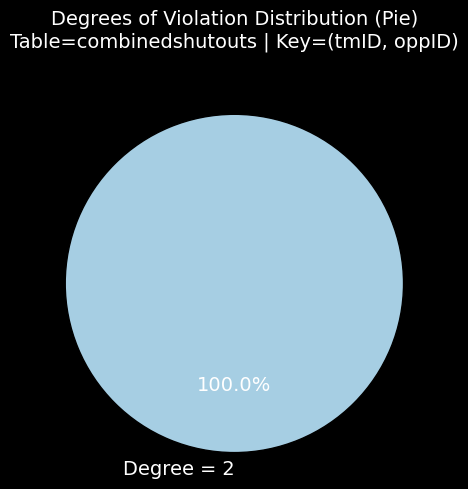


--- Table=combinedshutouts | Key=(tmID, oppID) | Degree=2 | Rows=1 ---
+---+------+-------+-------------+
| # | tmID | oppID | group_count |
+---+------+-------+-------------+
| 1 | TOR  |  CLF  |      2      |
+---+------+-------+-------------+

==================== Table: combinedshutouts; Near-key: ('oppID', 'IDgoalie1') ====================



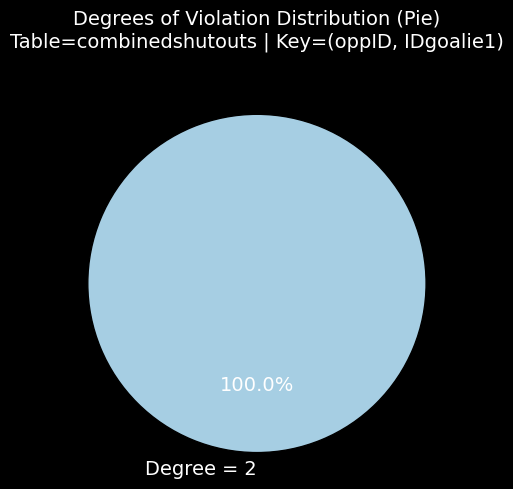


--- Table=combinedshutouts | Key=(oppID, IDgoalie1) | Degree=2 | Rows=1 ---
+---+-------+-----------+-------------+
| # | oppID | IDgoalie1 | group_count |
+---+-------+-----------+-------------+
| 1 |  CLF  | plantja01 |      2      |
+---+-------+-----------+-------------+

==================== Table: combinedshutouts; Near-key: ('month', 'R/P', 'IDgoalie2') ====================



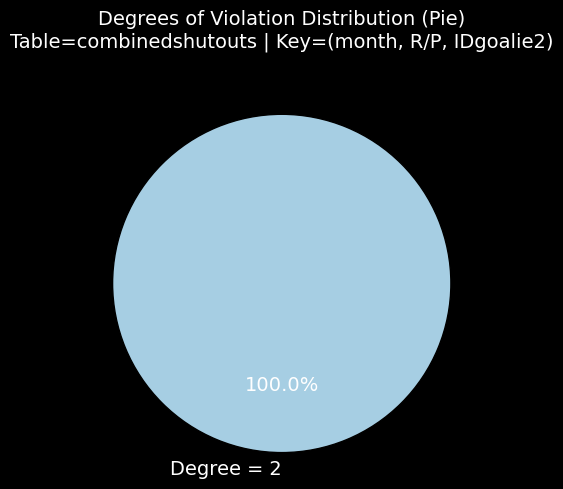


--- Table=combinedshutouts | Key=(month, R/P, IDgoalie2) | Degree=2 | Rows=1 ---
+---+-------+-----+-----------+-------------+
| # | month | R/P | IDgoalie2 | group_count |
+---+-------+-----+-----------+-------------+
| 1 |   10  |  R  | legacma01 |      2      |
+---+-------+-----+-----------+-------------+

==================== Table: combinedshutouts; Near-key: ('tmID', 'oppID', 'R/P') ====================



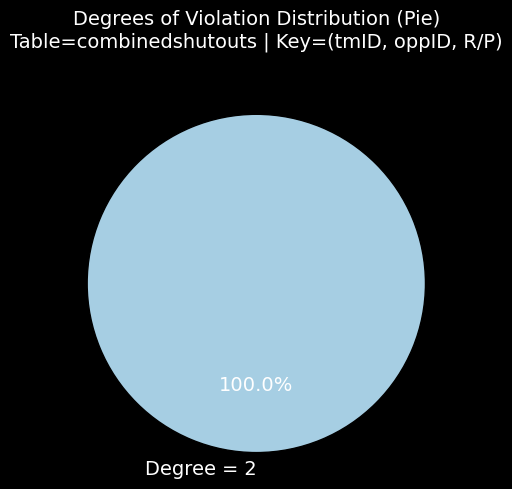


--- Table=combinedshutouts | Key=(tmID, oppID, R/P) | Degree=2 | Rows=1 ---
+---+------+-------+-----+-------------+
| # | tmID | oppID | R/P | group_count |
+---+------+-------+-----+-------------+
| 1 | TOR  |  CLF  |  R  |      2      |
+---+------+-------+-----+-------------+

==================== Table: combinedshutouts; Near-key: ('tmID', 'oppID', 'IDgoalie1') ====================



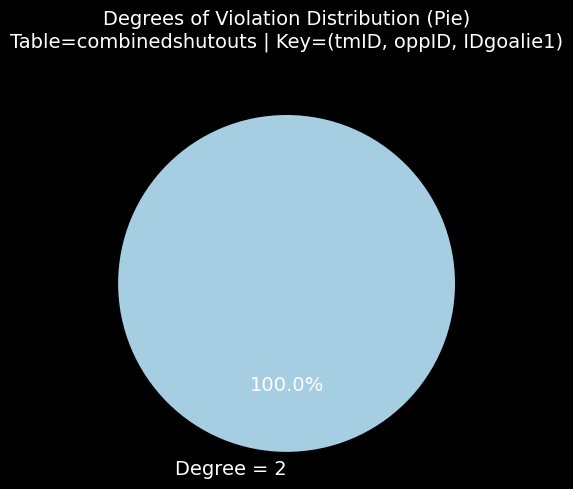


--- Table=combinedshutouts | Key=(tmID, oppID, IDgoalie1) | Degree=2 | Rows=1 ---
+---+------+-------+-----------+-------------+
| # | tmID | oppID | IDgoalie1 | group_count |
+---+------+-------+-----------+-------------+
| 1 | TOR  |  CLF  | plantja01 |      2      |
+---+------+-------+-----------+-------------+

==================== Table: combinedshutouts; Near-key: ('oppID', 'R/P', 'IDgoalie1') ====================



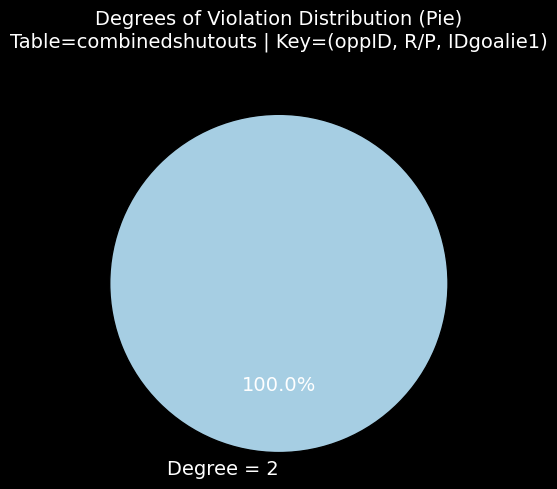


--- Table=combinedshutouts | Key=(oppID, R/P, IDgoalie1) | Degree=2 | Rows=1 ---
+---+-------+-----+-----------+-------------+
| # | oppID | R/P | IDgoalie1 | group_count |
+---+-------+-----+-----------+-------------+
| 1 |  CLF  |  R  | plantja01 |      2      |
+---+-------+-----+-----------+-------------+

==================== Table: combinedshutouts; Near-key: ('tmID', 'oppID', 'R/P', 'IDgoalie1') ====================



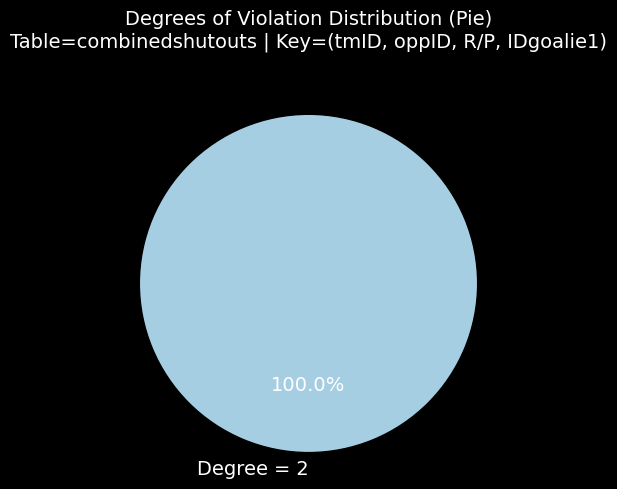


--- Table=combinedshutouts | Key=(tmID, oppID, R/P, IDgoalie1) | Degree=2 | Rows=1 ---
+---+------+-------+-----+-----------+-------------+
| # | tmID | oppID | R/P | IDgoalie1 | group_count |
+---+------+-------+-----+-----------+-------------+
| 1 | TOR  |  CLF  |  R  | plantja01 |      2      |
+---+------+-------+-----+-----------+-------------+

==================== Table: goalies; Near-key: ('playerID', 'year', 'tmID') ====================



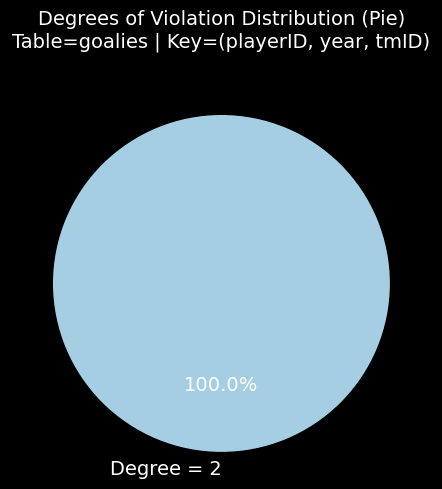


--- Table=goalies | Key=(playerID, year, tmID) | Degree=2 | Rows=1 ---
+---+-----------+------+------+-------------+
| # |  playerID | year | tmID | group_count |
+---+-----------+------+------+-------------+
| 1 | mattsma01 | 1977 | WIJ  |      2      |
+---+-----------+------+------+-------------+

==================== Table: goalies; Near-key: ('playerID', 'year', 'GP') ====================



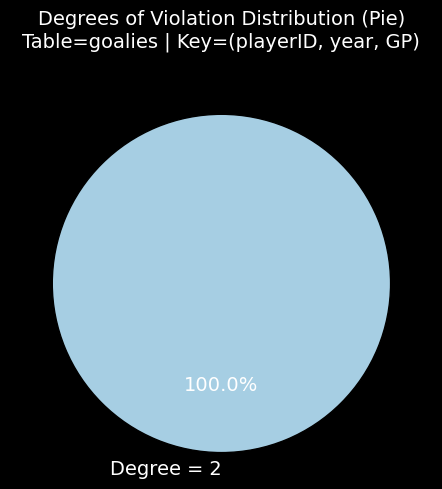


--- Table=goalies | Key=(playerID, year, GP) | Degree=2 | Rows=11 ---
+----+-----------+------+----+-------------+
| #  |  playerID | year | GP | group_count |
+----+-----------+------+----+-------------+
| 1  | caronse01 | 2006 | 1  |      2      |
| 2  |  fuhrgr01 | 1992 | 29 |      2      |
| 3  | garrejo01 | 1982 | 17 |      2      |
| 4  | hackeje01 | 2002 | 18 |      2      |
| 5  | holdebi01 | 1973 | 1  |      2      |
| 6  | mattsma01 | 1977 | 6  |      2      |
| 7  | mcelhcu01 | 2009 | 10 |      2      |
| 8  | noronmi01 | 2005 | 4  |      2      |
| 9  | pietrfr01 | 1991 | 5  |      2      |
| 10 | shtalmi01 | 1999 | 15 |      2      |
| 11 | smithga01 | 1978 | 11 |      2      |
+----+-----------+------+----+-------------+

==================== Table: goalies; Near-key: ('year', 'tmID', 'GP') ====================



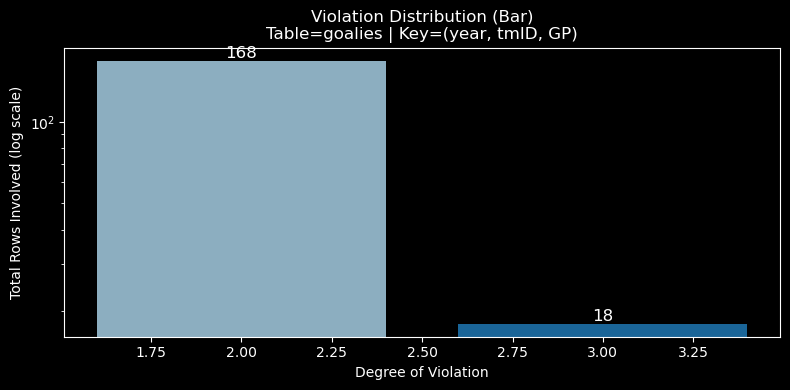

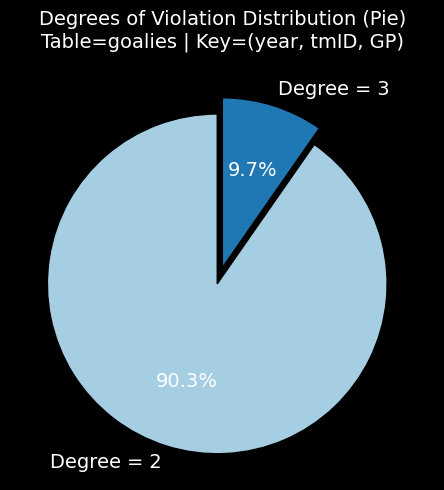


--- Table=goalies | Key=(year, tmID, GP) | Degree=3 | Rows=6 ---
+---+------+------+----+-------------+
| # | year | tmID | GP | group_count |
+---+------+------+----+-------------+
| 1 | 1943 | BOS  | 1  |      3      |
| 2 | 1931 | NYA  | 1  |      3      |
| 3 | 1968 | STL  | 1  |      3      |
| 4 | 1933 | NYA  | 1  |      3      |
| 5 | 1931 | TOR  | 1  |      3      |
| 6 | 1963 | DET  | 1  |      3      |
+---+------+------+----+-------------+

--- Table=goalies | Key=(year, tmID, GP) | Degree=2 | Rows=84 ---
+----+------+------+----+-------------+
| #  | year | tmID | GP | group_count |
+----+------+------+----+-------------+
| 1  | 1984 | EDM  | 1  |      2      |
| 2  | 1972 | PHI  | 23 |      2      |
| 3  | 1991 | BOS  | 8  |      2      |
| 4  | 1990 | DET  | 3  |      2      |
| 5  | 1991 | DET  | 1  |      2      |
| 6  | 2003 | PHO  | 4  |      2      |
| 7  | 1993 | BOS  | 18 |      2      |
| 8  | 1974 | ATF  | 40 |      2      |
| 9  | 1939 | DET  | 1  |      2     

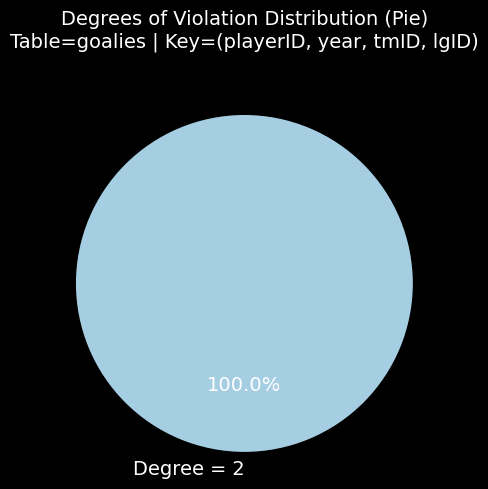


--- Table=goalies | Key=(playerID, year, tmID, lgID) | Degree=2 | Rows=1 ---
+---+-----------+------+------+------+-------------+
| # |  playerID | year | tmID | lgID | group_count |
+---+-----------+------+------+------+-------------+
| 1 | mattsma01 | 1977 | WIJ  | WHA  |      2      |
+---+-----------+------+------+------+-------------+

==================== Table: goalies; Near-key: ('playerID', 'year', 'lgID', 'GP') ====================



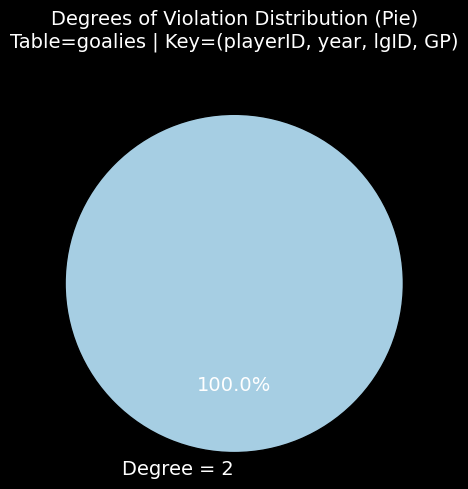


--- Table=goalies | Key=(playerID, year, lgID, GP) | Degree=2 | Rows=11 ---
+----+-----------+------+------+----+-------------+
| #  |  playerID | year | lgID | GP | group_count |
+----+-----------+------+------+----+-------------+
| 1  | caronse01 | 2006 | NHL  | 1  |      2      |
| 2  |  fuhrgr01 | 1992 | NHL  | 29 |      2      |
| 3  | garrejo01 | 1982 | NHL  | 17 |      2      |
| 4  | hackeje01 | 2002 | NHL  | 18 |      2      |
| 5  | holdebi01 | 1973 | WHA  | 1  |      2      |
| 6  | mattsma01 | 1977 | WHA  | 6  |      2      |
| 7  | mcelhcu01 | 2009 | NHL  | 10 |      2      |
| 8  | noronmi01 | 2005 | NHL  | 4  |      2      |
| 9  | pietrfr01 | 1991 | NHL  | 5  |      2      |
| 10 | shtalmi01 | 1999 | NHL  | 15 |      2      |
| 11 | smithga01 | 1978 | WHA  | 11 |      2      |
+----+-----------+------+------+----+-------------+

==================== Table: goalies; Near-key: ('year', 'stint', 'tmID', 'GP') ====================



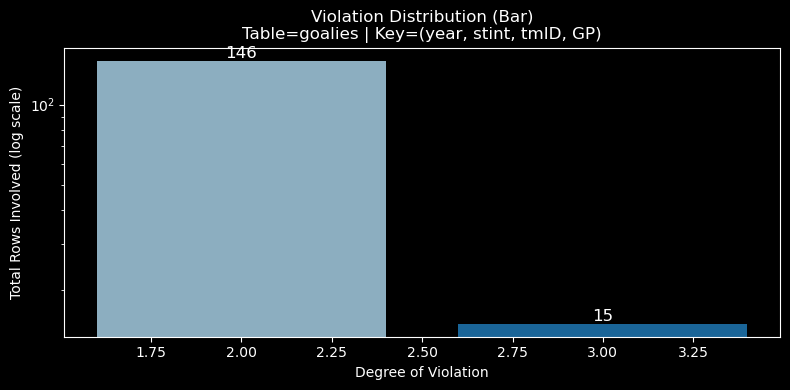

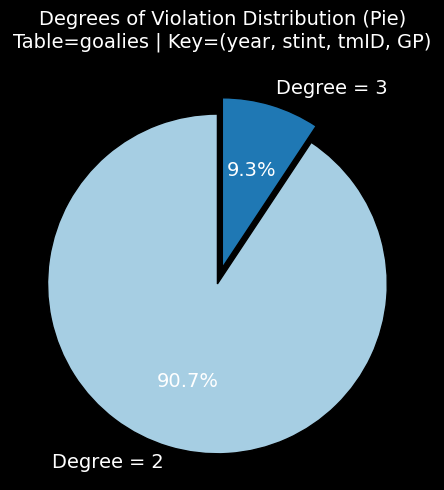


--- Table=goalies | Key=(year, stint, tmID, GP) | Degree=3 | Rows=5 ---
+---+------+-------+------+----+-------------+
| # | year | stint | tmID | GP | group_count |
+---+------+-------+------+----+-------------+
| 1 | 1943 |   1   | BOS  | 1  |      3      |
| 2 | 1931 |   1   | NYA  | 1  |      3      |
| 3 | 1968 |   1   | STL  | 1  |      3      |
| 4 | 1931 |   1   | TOR  | 1  |      3      |
| 5 | 1963 |   1   | DET  | 1  |      3      |
+---+------+-------+------+----+-------------+

--- Table=goalies | Key=(year, stint, tmID, GP) | Degree=2 | Rows=73 ---
+----+------+-------+------+----+-------------+
| #  | year | stint | tmID | GP | group_count |
+----+------+-------+------+----+-------------+
| 1  | 1984 |   1   | EDM  | 1  |      2      |
| 2  | 1979 |   1   | BOS  | 1  |      2      |
| 3  | 1972 |   1   | PHI  | 23 |      2      |
| 4  | 1991 |   1   | BOS  | 8  |      2      |
| 5  | 1991 |   1   | DET  | 1  |      2      |
| 6  | 2003 |   1   | PHO  | 4  |      2      

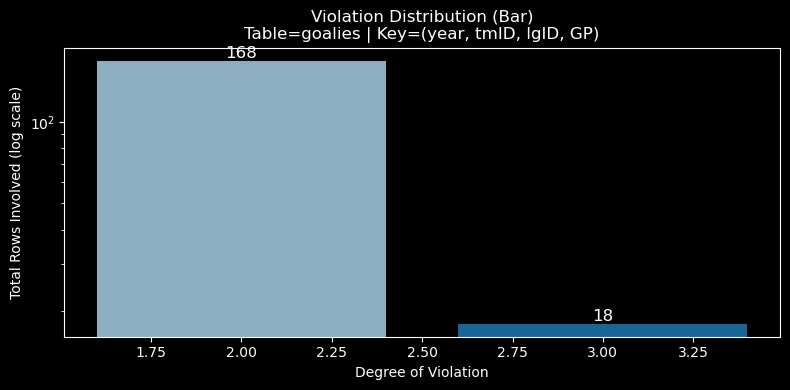

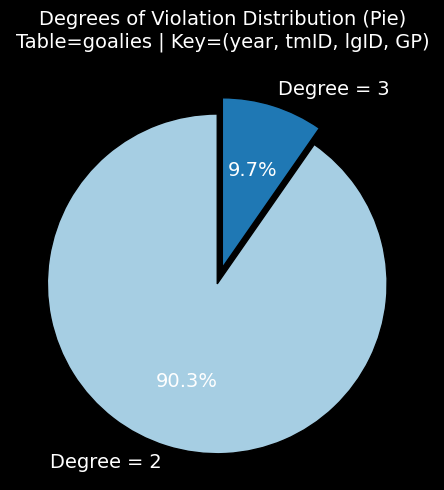


--- Table=goalies | Key=(year, tmID, lgID, GP) | Degree=3 | Rows=6 ---
+---+------+------+------+----+-------------+
| # | year | tmID | lgID | GP | group_count |
+---+------+------+------+----+-------------+
| 1 | 1943 | BOS  | NHL  | 1  |      3      |
| 2 | 1931 | NYA  | NHL  | 1  |      3      |
| 3 | 1968 | STL  | NHL  | 1  |      3      |
| 4 | 1933 | NYA  | NHL  | 1  |      3      |
| 5 | 1931 | TOR  | NHL  | 1  |      3      |
| 6 | 1963 | DET  | NHL  | 1  |      3      |
+---+------+------+------+----+-------------+

--- Table=goalies | Key=(year, tmID, lgID, GP) | Degree=2 | Rows=84 ---
+----+------+------+------+----+-------------+
| #  | year | tmID | lgID | GP | group_count |
+----+------+------+------+----+-------------+
| 1  | 1984 | EDM  | NHL  | 1  |      2      |
| 2  | 1972 | PHI  | NHL  | 23 |      2      |
| 3  | 1991 | BOS  | NHL  | 8  |      2      |
| 4  | 1990 | DET  | NHL  | 3  |      2      |
| 5  | 1991 | DET  | NHL  | 1  |      2      |
| 6  | 2003 | PHO  

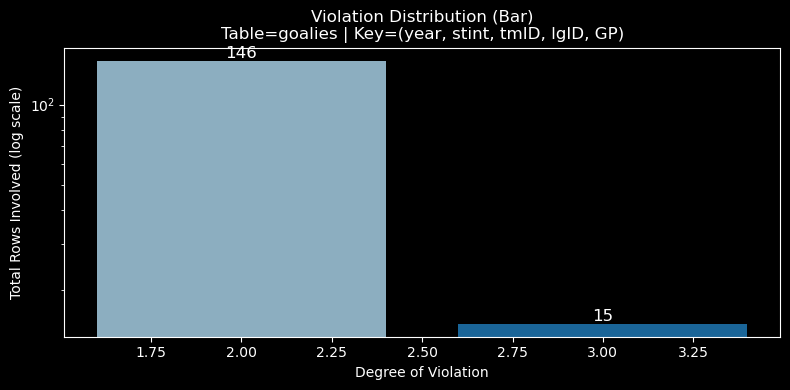

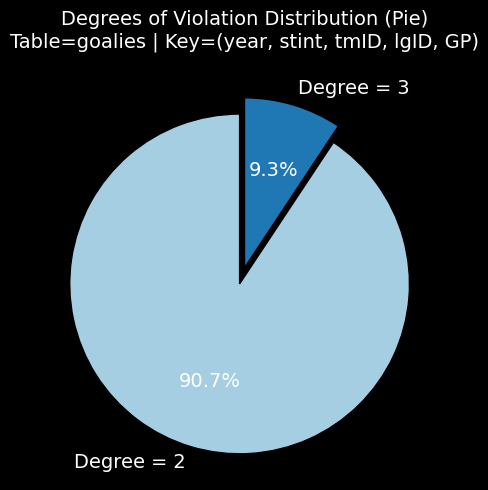


--- Table=goalies | Key=(year, stint, tmID, lgID, GP) | Degree=3 | Rows=5 ---
+---+------+-------+------+------+----+-------------+
| # | year | stint | tmID | lgID | GP | group_count |
+---+------+-------+------+------+----+-------------+
| 1 | 1943 |   1   | BOS  | NHL  | 1  |      3      |
| 2 | 1931 |   1   | NYA  | NHL  | 1  |      3      |
| 3 | 1968 |   1   | STL  | NHL  | 1  |      3      |
| 4 | 1931 |   1   | TOR  | NHL  | 1  |      3      |
| 5 | 1963 |   1   | DET  | NHL  | 1  |      3      |
+---+------+-------+------+------+----+-------------+

--- Table=goalies | Key=(year, stint, tmID, lgID, GP) | Degree=2 | Rows=73 ---
+----+------+-------+------+------+----+-------------+
| #  | year | stint | tmID | lgID | GP | group_count |
+----+------+-------+------+------+----+-------------+
| 1  | 1984 |   1   | EDM  | NHL  | 1  |      2      |
| 2  | 1979 |   1   | BOS  | NHL  | 1  |      2      |
| 3  | 1972 |   1   | PHI  | NHL  | 23 |      2      |
| 4  | 1991 |   1   | BOS

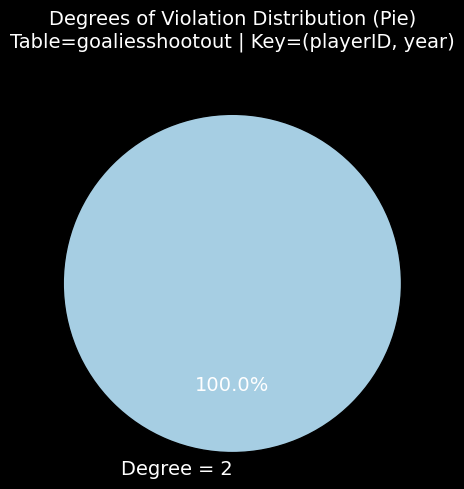


--- Table=goaliesshootout | Key=(playerID, year) | Degree=2 | Rows=11 ---
+----+-----------+------+-------------+
| #  |  playerID | year | group_count |
+----+-----------+------+-------------+
| 1  | andercr01 | 2010 |      2      |
| 2  | bryzgil01 | 2007 |      2      |
| 3  | elliobr01 | 2010 |      2      |
| 4  | gigueje01 | 2009 |      2      |
| 5  |  huetcr01 | 2007 |      2      |
| 6  | labarja01 | 2008 |      2      |
| 7  | leighmi01 | 2009 |      2      |
| 8  | macdojo01 | 2006 |      2      |
| 9  | mcelhcu01 | 2009 |      2      |
| 10 | rolosdw01 | 2005 |      2      |
| 11 | rolosdw01 | 2010 |      2      |
+----+-----------+------+-------------+

==================== Table: hof; Near-key: ('name',) ====================



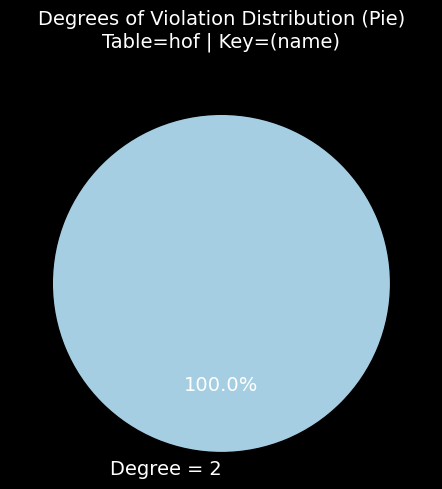


--- Table=hof | Key=(name) | Degree=2 | Rows=1 ---
+---+--------------+-------------+
| # |     name     | group_count |
+---+--------------+-------------+
| 1 | Harry Watson |      2      |
+---+--------------+-------------+

==================== Table: hof; Near-key: ('name', 'category') ====================



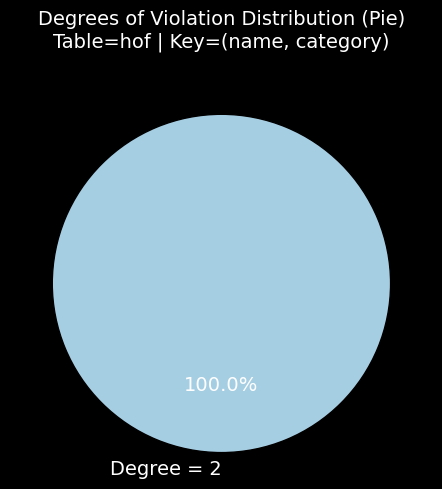


--- Table=hof | Key=(name, category) | Degree=2 | Rows=1 ---
+---+--------------+----------+-------------+
| # |     name     | category | group_count |
+---+--------------+----------+-------------+
| 1 | Harry Watson |  Player  |      2      |
+---+--------------+----------+-------------+

==================== Table: master; Near-key: ('lastName', 'nameGiven') ====================



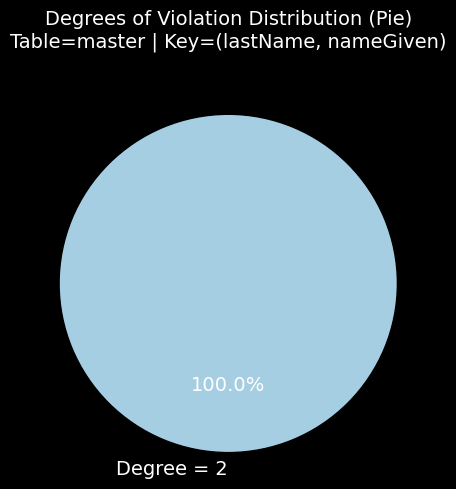


--- Table=master | Key=(lastName, nameGiven) | Degree=2 | Rows=6 ---
+---+-----------+----------------+-------------+
| # |  lastName |   nameGiven    | group_count |
+---+-----------+----------------+-------------+
| 1 | Andersson |     Peter      |      2      |
| 2 |  McCarthy | Thomas Joseph  |      2      |
| 3 |    Reid   |     David      |      2      |
| 4 |   Smith   |      Guy       |      2      |
| 5 |   Sykora  |      Petr      |      2      |
| 6 |   Harris  | William Edward |      2      |
+---+-----------+----------------+-------------+

==================== Table: master; Near-key: ('lastName', 'birthYear') ====================



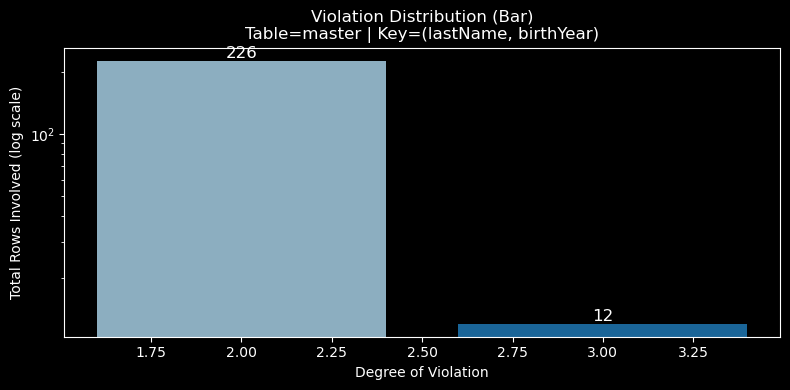

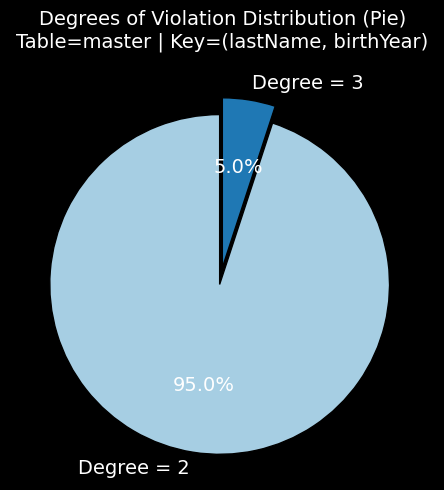


--- Table=master | Key=(lastName, birthYear) | Degree=3 | Rows=4 ---
+---+----------+-----------+-------------+
| # | lastName | birthYear | group_count |
+---+----------+-----------+-------------+
| 1 |  Smith   |    1963   |      3      |
| 2 |  Wilson  |    1962   |      3      |
| 3 |  Smith   |    1950   |      3      |
| 4 |  Smith   |    1977   |      3      |
+---+----------+-----------+-------------+

--- Table=master | Key=(lastName, birthYear) | Degree=2 | Rows=113 ---
+-----+-------------+-----------+-------------+
|  #  |   lastName  | birthYear | group_count |
+-----+-------------+-----------+-------------+
|  1  | Abrahamsson |    1947   |      2      |
|  2  |    Adams    |    1977   |      2      |
|  3  |    Adams    |    1904   |      2      |
|  4  |    Allen    |    1978   |      2      |
|  5  |   Allison   |    1959   |      2      |
|  6  |   Allison   |    1975   |      2      |
|  7  |  Andersson  |    1971   |      2      |
|  8  |    Brown    |    1917   | 

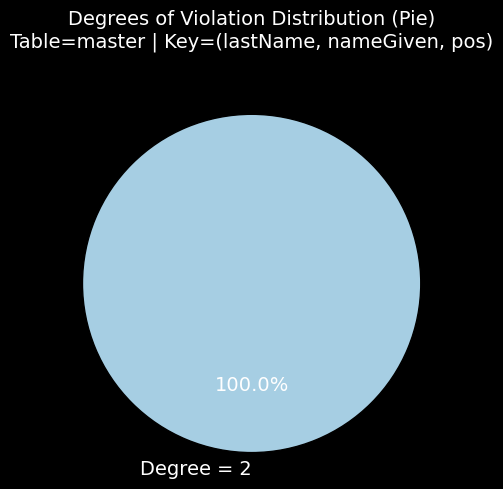


--- Table=master | Key=(lastName, nameGiven, pos) | Degree=2 | Rows=1 ---
+---+-----------+-----------+-----+-------------+
| # |  lastName | nameGiven | pos | group_count |
+---+-----------+-----------+-----+-------------+
| 1 | Andersson |   Peter   |  D  |      2      |
+---+-----------+-----------+-----+-------------+

==================== Table: master; Near-key: ('lastName', 'birthYear', 'pos') ====================



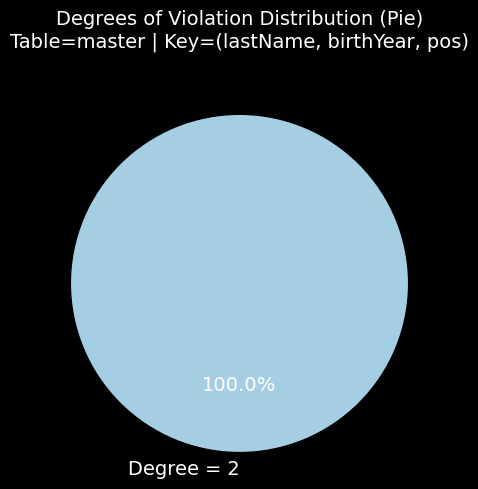


--- Table=master | Key=(lastName, birthYear, pos) | Degree=2 | Rows=23 ---
+----+-----------+-----------+-----+-------------+
| #  |  lastName | birthYear | pos | group_count |
+----+-----------+-----------+-----+-------------+
| 1  |   Allen   |    1978   |  D  |      2      |
| 2  | Andersson |    1971   |  L  |      2      |
| 3  |   Morgan  |    1976   |  C  |      2      |
| 4  |  Stevens  |    1965   |  L  |      2      |
| 5  |   Henry   |    1979   |  D  |      2      |
| 6  |   Smith   |    1964   |  D  |      2      |
| 7  |   Watson  |    1943   |  D  |      2      |
| 8  |  Mitchell |    1985   |  C  |      2      |
| 9  |  Mueller  |    1988   |  C  |      2      |
| 10 |  Boucher  |    1896   |  D  |      2      |
| 11 | Johansson |    1967   |  D  |      2      |
| 12 |   Smith   |    1973   |  D  |      2      |
| 13 |   Brown   |    1960   |  D  |      2      |
| 14 |   Blake   |    1912   |  L  |      2      |
| 15 |    Orr    |    1948   |  D  |      2      |
| 16 |

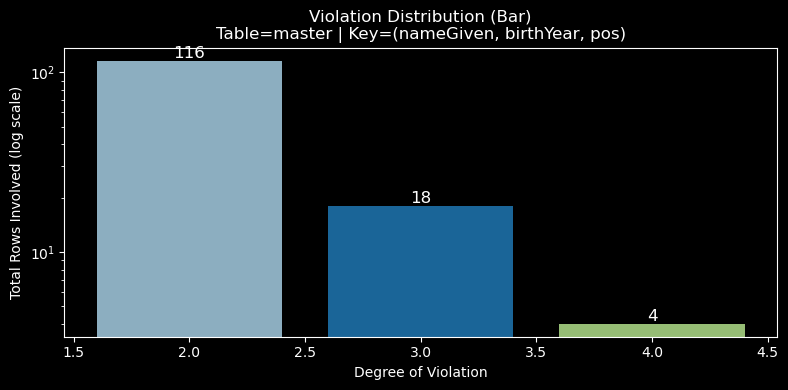

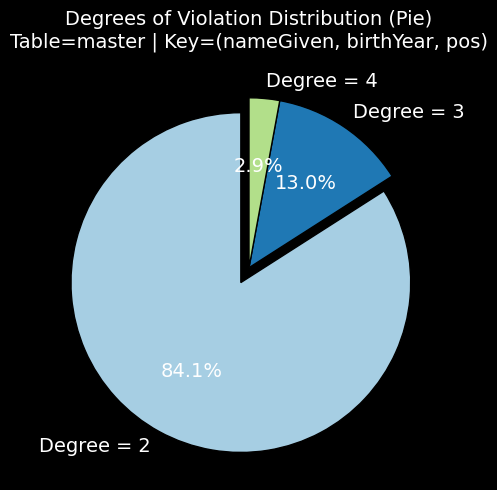


--- Table=master | Key=(nameGiven, birthYear, pos) | Degree=4 | Rows=1 ---
+---+-----------+-----------+-----+-------------+
| # | nameGiven | birthYear | pos | group_count |
+---+-----------+-----------+-----+-------------+
| 1 |  Michael  |    1966   |  C  |      4      |
+---+-----------+-----------+-----+-------------+

--- Table=master | Key=(nameGiven, birthYear, pos) | Degree=3 | Rows=6 ---
+---+-----------+-----------+-----+-------------+
| # | nameGiven | birthYear | pos | group_count |
+---+-----------+-----------+-----+-------------+
| 1 |   James   |    1967   |  D  |      3      |
| 2 |    Paul   |    1963   |  R  |      3      |
| 3 |    Dean   |    1968   |  D  |      3      |
| 4 |   Jason   |    1976   |  C  |      3      |
| 5 |   Scott   |    1969   |  L  |      3      |
| 6 |  Michael  |    1980   |  C  |      3      |
+---+-----------+-----------+-----+-------------+

--- Table=master | Key=(nameGiven, birthYear, pos) | Degree=2 | Rows=58 ---
+----+---------------

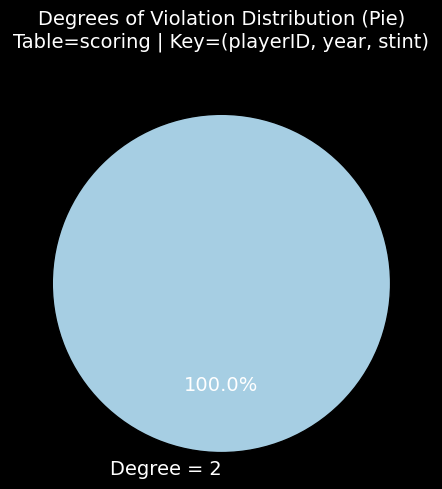


--- Table=scoring | Key=(playerID, year, stint) | Degree=2 | Rows=2 ---
+---+-----------+------+-------+-------------+
| # |  playerID | year | stint | group_count |
+---+-----------+------+-------+-------------+
| 1 | allenbr01 | 2011 |   1   |      2      |
| 2 | stonemi01 | 2011 |   1   |      2      |
+---+-----------+------+-------+-------------+

==================== Table: scoring; Near-key: ('playerID', 'year', 'tmID') ====================



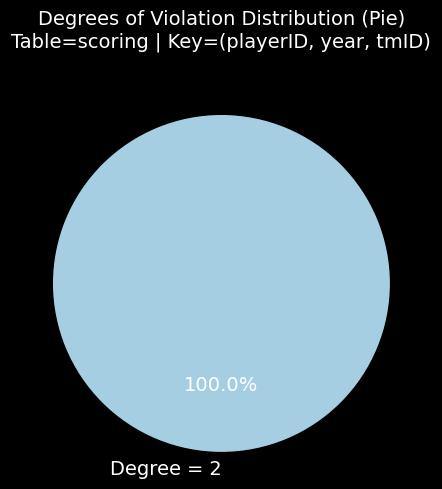


--- Table=scoring | Key=(playerID, year, tmID) | Degree=2 | Rows=9 ---
+---+-----------+------+------+-------------+
| # |  playerID | year | tmID | group_count |
+---+-----------+------+------+-------------+
| 1 | baltibr01 | 1978 | CIN  |      2      |
| 2 | cleghsp01 | 1920 | OTS  |      2      |
| 3 |  fordmi01 | 1976 | WIJ  |      2      |
| 4 | kennede01 | 1988 | LAK  |      2      |
| 5 | masnipa01 | 1954 | MTL  |      2      |
| 6 | mattsma01 | 1977 | WIJ  |      2      |
| 7 | millepe01 | 1975 | WIJ  |      2      |
| 8 | nedomva01 | 1982 | NYR  |      2      |
| 9 | skaldja01 | 1997 | CHI  |      2      |
+---+-----------+------+------+-------------+

==================== Table: scoring; Near-key: ('playerID', 'year', 'stint', 'lgID') ====================



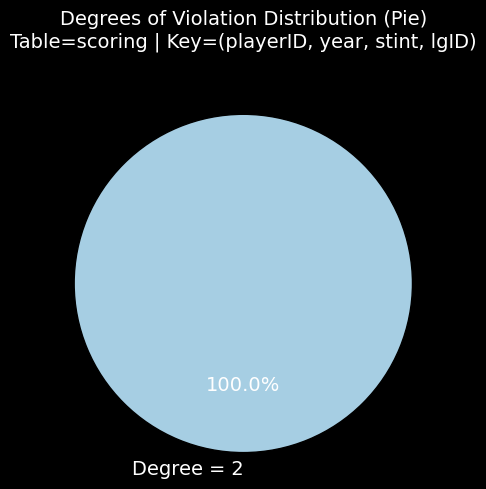


--- Table=scoring | Key=(playerID, year, stint, lgID) | Degree=2 | Rows=2 ---
+---+-----------+------+-------+------+-------------+
| # |  playerID | year | stint | lgID | group_count |
+---+-----------+------+-------+------+-------------+
| 1 | allenbr01 | 2011 |   1   | NHL  |      2      |
| 2 | stonemi01 | 2011 |   1   | NHL  |      2      |
+---+-----------+------+-------+------+-------------+

==================== Table: scoring; Near-key: ('playerID', 'year', 'tmID', 'lgID') ====================



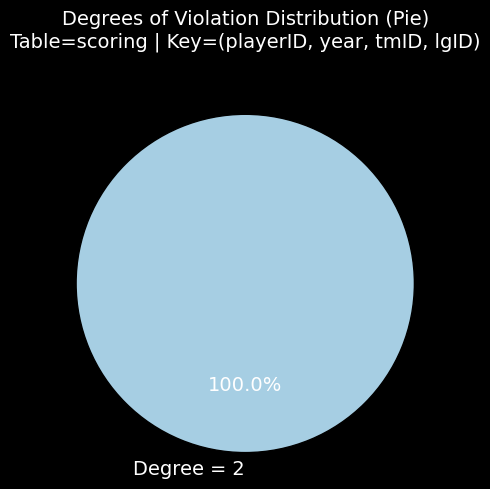


--- Table=scoring | Key=(playerID, year, tmID, lgID) | Degree=2 | Rows=9 ---
+---+-----------+------+------+------+-------------+
| # |  playerID | year | tmID | lgID | group_count |
+---+-----------+------+------+------+-------------+
| 1 | baltibr01 | 1978 | CIN  | WHA  |      2      |
| 2 | cleghsp01 | 1920 | OTS  | NHL  |      2      |
| 3 |  fordmi01 | 1976 | WIJ  | WHA  |      2      |
| 4 | kennede01 | 1988 | LAK  | NHL  |      2      |
| 5 | masnipa01 | 1954 | MTL  | NHL  |      2      |
| 6 | mattsma01 | 1977 | WIJ  | WHA  |      2      |
| 7 | millepe01 | 1975 | WIJ  | WHA  |      2      |
| 8 | nedomva01 | 1982 | NYR  | NHL  |      2      |
| 9 | skaldja01 | 1997 | CHI  | NHL  |      2      |
+---+-----------+------+------+------+-------------+

==================== Table: scoring; Near-key: ('playerID', 'year', 'tmID', 'pos') ====================



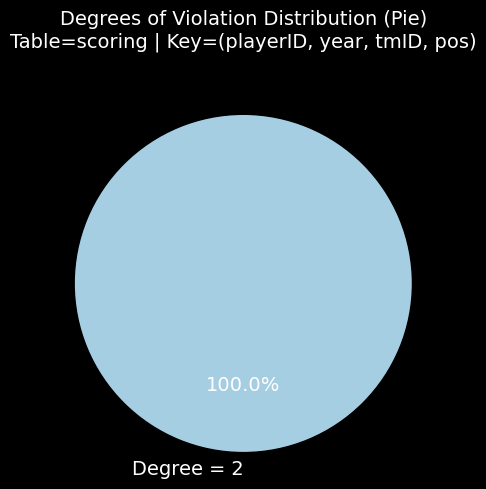


--- Table=scoring | Key=(playerID, year, tmID, pos) | Degree=2 | Rows=9 ---
+---+-----------+------+------+-----+-------------+
| # |  playerID | year | tmID | pos | group_count |
+---+-----------+------+------+-----+-------------+
| 1 | baltibr01 | 1978 | CIN  |  D  |      2      |
| 2 | cleghsp01 | 1920 | OTS  |  D  |      2      |
| 3 |  fordmi01 | 1976 | WIJ  |  D  |      2      |
| 4 | kennede01 | 1988 | LAK  |  D  |      2      |
| 5 | masnipa01 | 1954 | MTL  |  C  |      2      |
| 6 | mattsma01 | 1977 | WIJ  |  G  |      2      |
| 7 | millepe01 | 1975 | WIJ  |  D  |      2      |
| 8 | nedomva01 | 1982 | NYR  |  R  |      2      |
| 9 | skaldja01 | 1997 | CHI  |  C  |      2      |
+---+-----------+------+------+-----+-------------+

==================== Table: scoring; Near-key: ('playerID', 'year', 'tmID', 'lgID', 'pos') ====================



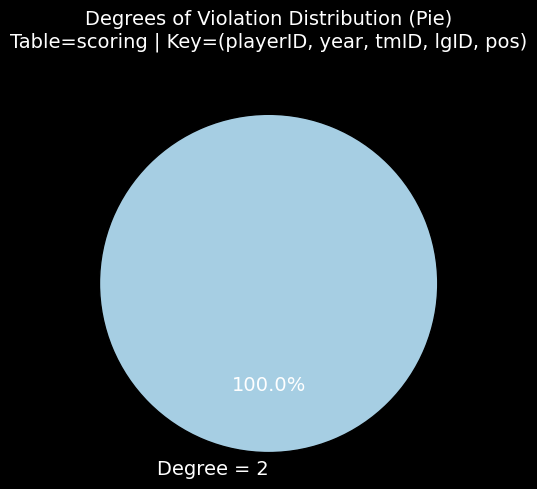


--- Table=scoring | Key=(playerID, year, tmID, lgID, pos) | Degree=2 | Rows=9 ---
+---+-----------+------+------+------+-----+-------------+
| # |  playerID | year | tmID | lgID | pos | group_count |
+---+-----------+------+------+------+-----+-------------+
| 1 | baltibr01 | 1978 | CIN  | WHA  |  D  |      2      |
| 2 | cleghsp01 | 1920 | OTS  | NHL  |  D  |      2      |
| 3 |  fordmi01 | 1976 | WIJ  | WHA  |  D  |      2      |
| 4 | kennede01 | 1988 | LAK  | NHL  |  D  |      2      |
| 5 | masnipa01 | 1954 | MTL  | NHL  |  C  |      2      |
| 6 | mattsma01 | 1977 | WIJ  | WHA  |  G  |      2      |
| 7 | millepe01 | 1975 | WIJ  | WHA  |  D  |      2      |
| 8 | nedomva01 | 1982 | NYR  | NHL  |  R  |      2      |
| 9 | skaldja01 | 1997 | CHI  | NHL  |  C  |      2      |
+---+-----------+------+------+------+-----+-------------+

==================== Table: seriespost; Near-key: ('year', 'tmIDLoser') ====================



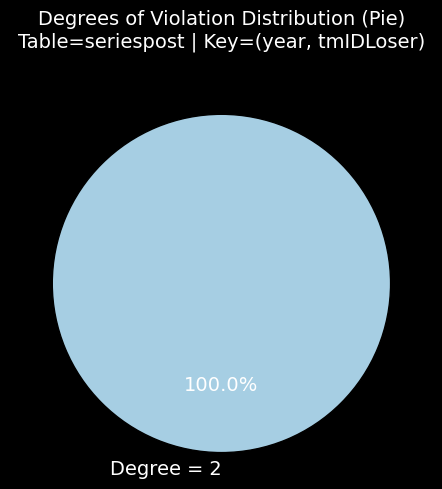


--- Table=seriespost | Key=(year, tmIDLoser) | Degree=2 | Rows=3 ---
+---+------+-----------+-------------+
| # | year | tmIDLoser | group_count |
+---+------+-----------+-------------+
| 1 | 1923 |    VAM    |      2      |
| 2 | 1975 |    SDM    |      2      |
| 3 | 1977 |    NEW    |      2      |
+---+------+-----------+-------------+

==================== Table: seriespost; Near-key: ('year', 'lgIDWinner', 'tmIDLoser') ====================



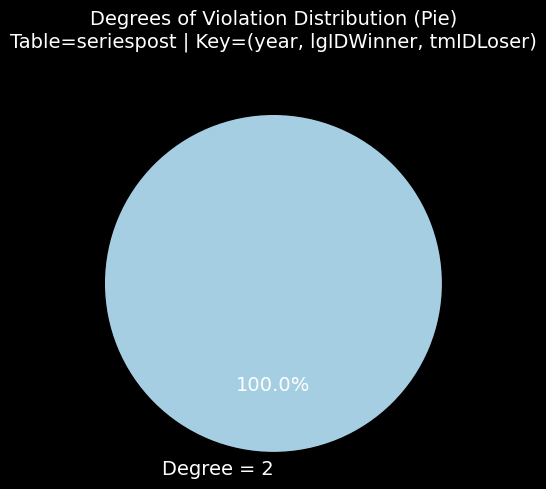


--- Table=seriespost | Key=(year, lgIDWinner, tmIDLoser) | Degree=2 | Rows=2 ---
+---+------+------------+-----------+-------------+
| # | year | lgIDWinner | tmIDLoser | group_count |
+---+------+------------+-----------+-------------+
| 1 | 1975 |    WHA     |    SDM    |      2      |
| 2 | 1977 |    WHA     |    NEW    |      2      |
+---+------+------------+-----------+-------------+

==================== Table: seriespost; Near-key: ('year', 'tmIDLoser', 'lgIDLoser') ====================



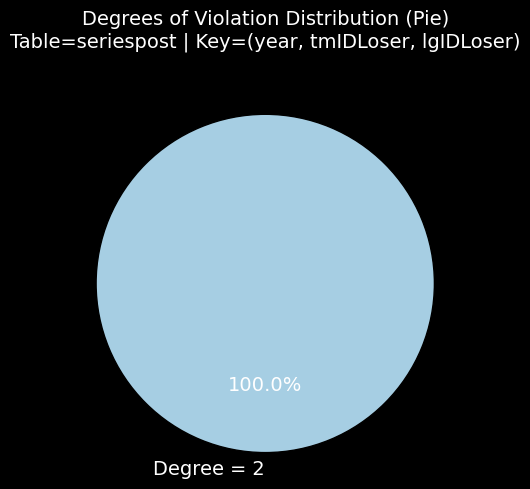


--- Table=seriespost | Key=(year, tmIDLoser, lgIDLoser) | Degree=2 | Rows=3 ---
+---+------+-----------+-----------+-------------+
| # | year | tmIDLoser | lgIDLoser | group_count |
+---+------+-----------+-----------+-------------+
| 1 | 1923 |    VAM    |    PCHA   |      2      |
| 2 | 1975 |    SDM    |    WHA    |      2      |
| 3 | 1977 |    NEW    |    WHA    |      2      |
+---+------+-----------+-----------+-------------+

==================== Table: seriespost; Near-key: ('year', 'lgIDWinner', 'tmIDLoser', 'lgIDLoser') ====================



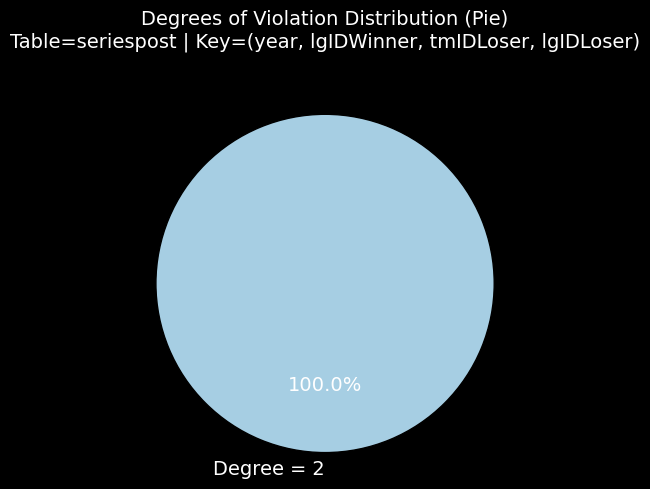


--- Table=seriespost | Key=(year, lgIDWinner, tmIDLoser, lgIDLoser) | Degree=2 | Rows=2 ---
+---+------+------------+-----------+-----------+-------------+
| # | year | lgIDWinner | tmIDLoser | lgIDLoser | group_count |
+---+------+------------+-----------+-----------+-------------+
| 1 | 1975 |    WHA     |    SDM    |    WHA    |      2      |
| 2 | 1977 |    WHA     |    NEW    |    WHA    |      2      |
+---+------+------------+-----------+-----------+-------------+


In [7]:
# -------------------------------------------------
# Degree distribution (your logic)
# duplicate_counts[degree] = total rows involved for this degree
# -------------------------------------------------
def degree_of_violation(cursor, table_name, columns):
    if not columns:
        return {}

    cols_sql = ", ".join([f"`{col}`" for col in columns])
    not_null_cond = " AND ".join([f"`{col}` IS NOT NULL" for col in columns])

    query_duplicates = f"""
        SELECT {cols_sql}, COUNT(*) AS group_count
        FROM `{table_name}`
        WHERE {not_null_cond}
        GROUP BY {cols_sql}
        HAVING COUNT(*) > 1;
    """

    cursor.execute(query_duplicates)
    group_table = cursor.fetchall()

    duplicate_counts = {}
    for row in group_table:
        degree = int(row[-1])
        duplicate_counts[degree] = duplicate_counts.get(degree, 0) + degree

    return duplicate_counts


# -------------------------------------------------
# Fetch duplicate detailed rows (show repeated field values)
# Return:
#   {degree: [row_dict, row_dict, ...]}
# -------------------------------------------------
def fetch_duplicate_rows(cursor, table_name, columns):
    if not columns:
        return {}

    # ✅ 统一用别名
    cols_t = ", ".join([f"t.`{col}`" for col in columns])
    cols_dup = ", ".join([f"dup.`{col}`" for col in columns])
    not_null_t = " AND ".join([f"t.`{col}` IS NOT NULL" for col in columns])
    not_null_dup = " AND ".join([f"dup.`{col}` IS NOT NULL" for col in columns])

    join_eq = " AND ".join([f"t.`{col}` = dup.`{col}`" for col in columns])

    query = f"""
        SELECT
            {cols_t},
            MAX(dup.group_count) AS group_count
        FROM `{table_name}` t
        JOIN (
            SELECT {", ".join([f"`{col}`" for col in columns])}, COUNT(*) AS group_count
            FROM `{table_name}`
            WHERE {" AND ".join([f"`{col}` IS NOT NULL" for col in columns])}
            GROUP BY {", ".join([f"`{col}`" for col in columns])}
            HAVING COUNT(*) > 1
        ) dup
          ON {join_eq}
        WHERE {not_null_t} AND {not_null_dup}
        GROUP BY {cols_t}
        ORDER BY group_count DESC;
    """


    cursor.execute(query)
    rows = cursor.fetchall()

    col_names = [desc[0] for desc in cursor.description]
    degree_idx = len(col_names) - 1

    grouped = {}
    for r in rows:
        degree = int(r[degree_idx])
        row_dict = {col_names[i]: r[i] for i in range(len(col_names))}
        grouped.setdefault(degree, []).append(row_dict)

    return grouped

# -------------------------------------------------
# Plot bar chart (only if multiple degrees)
# -------------------------------------------------
def plot_violation_bar_chart(table_name, columns, degrees, values, colors):
    plt.figure(figsize=(8, 4))
    plt.bar(degrees, values, color=colors, alpha=0.85)

    plt.yscale("log")

    for x, y in zip(degrees, values):
        plt.text(x, y, str(y), fontsize=12, ha="center", va="bottom")

    plt.xlabel("Degree of Violation")
    plt.ylabel("Total Rows Involved (log scale)")
    plt.title(f"Violation Distribution (Bar)\nTable={table_name} | Key=({', '.join(columns)})")
    plt.tight_layout()
    plt.show()


# -------------------------------------------------
# Plot pie chart (always if duplicates exist)
# -------------------------------------------------
def plot_violation_pie_chart(table_name, columns, degrees, ratios, colors):
    labels = [f"Degree = {degree}" for degree in degrees]
    explode = [0.1 if i == 0 else 0 for i in range(len(labels))]

    plt.figure(figsize=(5, 5))
    plt.pie(
        ratios,
        labels=labels,
        autopct="%1.1f%%",
        startangle=90,
        colors=colors,
        explode=explode,
        wedgeprops={"edgecolor": "black"},
        textprops={"fontsize": 14},
    )

    plt.title(
        f"Degrees of Violation Distribution (Pie)\nTable={table_name} | Key=({', '.join(columns)})",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()


# -------------------------------------------------
# Print duplicate details grouped by degree
# -------------------------------------------------
def print_duplicate_details(table_name, columns, grouped_rows, max_rows_per_degree=20):
    """
    grouped_rows: {degree: [row_dict, ...]}
    """
    if not grouped_rows:
        print("[INFO] No duplicate rows to display.")
        return

    # determine display columns: only show key columns + group_count
    display_cols = list(columns) + ["group_count"]

    for degree in sorted(grouped_rows.keys(), reverse=True):
        rows = grouped_rows[degree]
        print(f"\n--- Table={table_name} | Key=({', '.join(columns)}) | Degree={degree} | Rows={len(rows)} ---")

        pt = PrettyTable()
        pt.field_names = ["#"] + display_cols

        limit = len(rows) if max_rows_per_degree is None else min(len(rows), max_rows_per_degree)

        for i in range(limit):
            r = rows[i]
            pt.add_row([i + 1] + [r.get(col) for col in display_cols])

        print(pt)

        if max_rows_per_degree is not None and len(rows) > max_rows_per_degree:
            print(f"[INFO] Showing only first {max_rows_per_degree} rows for Degree={degree}.")


# -------------------------------------------------
# Main wrapper: plot + show duplicate details
# -------------------------------------------------
def main_degree(table_name, columns, max_rows_per_degree=20):
    connection = None
    cursor = None

    try:
        connection = get_mysql_connection()
        cursor = connection.cursor()

        # 1) degree distribution
        duplicate_counts = degree_of_violation(cursor, table_name, columns)

        if not duplicate_counts:
            print(f"[INFO] No duplicates found: Table={table_name}, Key=({', '.join(columns)})")
            return

        degrees = sorted(duplicate_counts.keys())
        values = [duplicate_counts[d] for d in degrees]

        total = sum(values)
        if total == 0:
            print(f"[INFO] Duplicate total is 0: Table={table_name}, Key=({', '.join(columns)})")
            return

        ratios = [v / total * 100 for v in values]

        # color mapping (consistent)
        palette = list(plt.cm.Paired.colors)
        colors = [palette[i % len(palette)] for i in range(len(degrees))]

        # 2) bar chart only if multiple degrees
        if len(degrees) > 1:
            plot_violation_bar_chart(table_name, columns, degrees, values, colors)

        # 3) pie chart always
        plot_violation_pie_chart(table_name, columns, degrees, ratios, colors)

        # 4) duplicate details
        grouped_rows = fetch_duplicate_rows(cursor, table_name, columns)
        print_duplicate_details(table_name, columns, grouped_rows, max_rows_per_degree=max_rows_per_degree)

    except Error as e:
        print("[ERROR]", e)

    finally:
        if cursor is not None:
            cursor.close()
        if connection is not None and connection.is_connected():
            connection.close()


path = "ur_result/near_key_all.csv"
near_keys = []
with open(path, mode="r", newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        table_name = row["table_name"]
        combo = tuple(x.strip() for x in row["key"].split(",") if x.strip())
        ur = float(row["UR(max)"])
        cr = float(row["CR"])
        near_keys.append((table_name, combo, ur, cr))
print(f"[OK] loaded {len(near_keys)} near-keys from: {path}")


for table_name, combo, ur, cr in near_keys:
    if ur != 1.0:
        print(f"\n==================== Table: {table_name}; Near-key: {combo} ====================\n")
        main_degree(table_name, list(combo), max_rows_per_degree=None)

# --- specialisation analysis ---

In [8]:



# ============================================================
# 1) Read near_key_all.csv -> pick UR(max)==1 keys
# ============================================================
def load_urmax_1_keys(near_key_csv_path="near_key_all.csv"):
    table_keys = {}

    with open(near_key_csv_path, mode="r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            table_name = row["table_name"].strip()
            key_tuple = tuple(x.strip() for x in row["key"].split(",") if x.strip())
            ur = float(row["UR(max)"])

            if ur == 1.0:
                table_keys.setdefault(table_name, []).append(key_tuple)

    return table_keys


# ============================================================
# 2) Read ur_result/{table_name}_result.csv -> data_dic
# ============================================================
def load_table_result_csv(table_name, folder="ur_result"):
    csv_path = os.path.join(folder, f"{table_name}_result.csv")

    data_dic = {}

    with open(csv_path, mode="r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)

        for row in reader:
            perm = tuple(x.strip() for x in row["key"].split(",") if x.strip())

            pur = float(row["max"])
            cur = float(row["min"])
            cr = float(row["CR"])

            tmax = float(row["max_time"])
            tmin = float(row["min_time"])

            data_dic[perm] = {
                "PUR": pur,
                "CUR": cur,
                "CR": cr,
                "Tmax": tmax,
                "Tmin": tmin,
            }

    # add empty set node
    data_dic[("φ",)] = {"PUR": 0.0, "CUR": 0.0, "CR": 1.0, "Tmax": 0.0, "Tmin": 0.0}

    return data_dic


# ============================================================
# 3) Subset helper
# ============================================================
def is_subset(super_set, sub_set):
    if str(sub_set) == "φ" or sub_set == ("φ",):
        return True
    return set(sub_set).issubset(set(super_set)) and set(super_set) != set(sub_set)


# ============================================================
# 4) BFS / Normal / DFS (your logic, slight fix for φ tuple)
# ============================================================
def bfs_subkey(key, data_dic):
    sub_column = []
    pur_dic, cur_dic, cr_dic = {}, {}, {}
    check_list = []

    for r in range(len(key), 0, -1):
        subsets = list(itertools.combinations(key, r))
        ll = []
        for subkey in subsets:
            pur = data_dic[subkey]["PUR"]
            flag = any(is_subset(check_key, subkey) for check_key in check_list)
            if not flag:
                ll.append(subkey)
                pur_dic[subkey] = pur
                cur_dic[subkey] = data_dic[subkey]["CUR"]
                cr_dic[subkey] = data_dic[subkey]["CR"]

                if pur < 0.95:
                    check_list.append(subkey)

        sub_column.append(ll)

    # add φ level
    # sub_column.append([("φ",)])
    # pur_dic[("φ",)] = 0.0
    # cur_dic[("φ",)] = 0.0
    # cr_dic[("φ",)] = 1.0

    return sub_column, pur_dic, cur_dic, cr_dic


def normal_subkey(key, data_dic):
    sub_column = []
    pur_dic, cur_dic, cr_dic = {}, {}, {}

    for r in range(1, len(key) + 1):
        subsets = list(itertools.combinations(key, r))
        sub_column.append(subsets)

    sub_column = sub_column[::-1]

    for sublist in sub_column:
        for subkey in sublist:
            pur_dic[subkey] = data_dic[subkey]["PUR"]
            cur_dic[subkey] = data_dic[subkey]["CUR"]
            cr_dic[subkey] = data_dic[subkey]["CR"]

    sub_column.append([("φ",)])
    pur_dic[("φ",)] = 0.0
    cur_dic[("φ",)] = 0.0
    cr_dic[("φ",)] = 1.0

    return sub_column, pur_dic, cur_dic, cr_dic


def dfs_subkey(key, data_dic):
    columns, pur_all, cur_all, cr_all = normal_subkey(key, data_dic)
    start_node = max([k for k in pur_all.keys() if k != ("φ",)], key=len)

    stack = [start_node]
    visited = set()
    result = []

    while stack:
        current_node = stack.pop()
        if current_node in visited:
            continue
        visited.add(current_node)

        pur = pur_all.get(current_node, None)
        if pur is None:
            continue

        result.append(current_node)
        if pur < 0.95:
            continue

        for i in range(len(current_node)):
            child_node = current_node[:i] + current_node[i + 1 :]
            if child_node not in visited:
                stack.append(child_node)

    result.sort(key=len, reverse=True)
    grouped_data = [list(group) for _, group in groupby(result, key=len)]

    # add φ at the end
    # grouped_data.append([("φ",)])

    pur_dic = {k: pur_all[k] for k in result}
    cur_dic = {k: cur_all[k] for k in result}
    cr_dic = {k: cr_all[k] for k in result}

    # pur_dic[("φ",)] = 0.0
    # cur_dic[("φ",)] = 0.0
    # cr_dic[("φ",)] = 1.0

    return grouped_data, pur_dic, cur_dic, cr_dic


# ============================================================
# 5) Abbreviation
# ============================================================
def abbreviate_key(node, abbr_map, sort_by_abbr=True):
    if node == ("φ",) or str(node) == "φ":
        return "φ"

    letters = [abbr_map.get(attr, attr[:1].upper()) for attr in node]
    if sort_by_abbr:
        letters = sorted(letters)
    return "".join(letters)


# ============================================================
# 6) Draw lattice with time on node labels (max/min time)
# ============================================================
def draw_vertical_lattice(
    data,
    node_spacing=4,
    node_size=8000,
    font_size=14,
    pur_ratios=None,
    cur_ratios=None,
    cr_ratios=None,
    pur_times=None,
    cur_times=None,
    abbr_map=None,
    title=None,
    save_path=None,   # ✅ 新增：传入保存路径（如果为 None 就不保存）
):
    G = nx.DiGraph()

    unique_nodes = {}
    for level_idx, level in enumerate(data):
        for node_idx, node in enumerate(level):
            unique_nodes.setdefault(node, {})
            unique_nodes[node]["pos"] = ((node_idx - len(level) / 2) * node_spacing, -level_idx)

    for node, attrs in unique_nodes.items():
        name = abbreviate_key(node, abbr_map) if abbr_map else ", ".join(node)

        pur = pur_ratios.get(node, 0.0) if pur_ratios else 0.0
        cur = cur_ratios.get(node, 0.0) if cur_ratios else 0.0
        cr = cr_ratios.get(node, 0.0) if cr_ratios else 0.0

        t_pur = pur_times.get(node, None) if pur_times else None
        t_cur = cur_times.get(node, None) if cur_times else None

        pur_time_str = f", {t_pur:.4f}s" if t_pur is not None else ""
        cur_time_str = f", {t_cur:.4f}s" if t_cur is not None else ""

        label = (
            f"{name}\n"
            f"max:{pur*100:.1f}%{pur_time_str}\n"
            f"min:{cur*100:.1f}%{cur_time_str}\n"
            f"CR:{cr*100:.1f}%"
        )

        G.add_node(node, pos=attrs["pos"], label=label)

    for level_idx in range(len(data) - 1):
        for parent in data[level_idx]:
            for child in data[level_idx + 1]:
                if is_subset(parent, child):
                    G.add_edge(parent, child)

    plt.figure(figsize=(18, 12), constrained_layout=True)

    # ✅ 强制白底（关键）
    plt.gcf().set_facecolor("white")
    plt.gca().set_facecolor("white")

    pos = nx.get_node_attributes(G, "pos")
    labels = nx.get_node_attributes(G, "label")

    nx.draw(
        G,
        pos,
        labels=labels,
        with_labels=True,
        node_size=node_size,
        node_color="skyblue",
        font_size=font_size,
        font_weight="bold",
        arrows=True,
    )

    if title:
        plt.title(title, fontsize=18)

    # ✅ 保存时也强制白底 + bbox_inches 防止裁剪异常
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")

    plt.close()




def draw_vertical_lattice_pruning(
    data,
    node_spacing=4,
    node_size=8000,
    font_size=14,
    pur_ratios=None,
    cur_ratios=None,
    cr_ratios=None,
    pur_times=None,
    cur_times=None,
    abbr_map=None,
    prune_threshold=0.95,
    title=None,
    save_path=None,   # ✅ 新增
):
    G = nx.DiGraph()

    unique_nodes = {}
    for level_idx, level in enumerate(data):
        for node_idx, node in enumerate(level):
            unique_nodes.setdefault(node, {})
            unique_nodes[node]["pos"] = ((node_idx - len(level) / 2) * node_spacing, -level_idx)

    for node, attrs in unique_nodes.items():
        name = abbreviate_key(node, abbr_map) if abbr_map else ", ".join(node)

        pur = pur_ratios.get(node, 0.0) if pur_ratios else 0.0
        cur = cur_ratios.get(node, 0.0) if cur_ratios else 0.0
        cr = cr_ratios.get(node, 0.0) if cr_ratios else 0.0

        t_pur = pur_times.get(node, None) if pur_times else None
        t_cur = cur_times.get(node, None) if cur_times else None

        pur_time_str = f", {t_pur:.4f}s" if t_pur is not None else ""
        cur_time_str = f", {t_cur:.4f}s" if t_cur is not None else ""

        label = (
            f"{name}\n"
            f"max:{pur*100:.1f}%{pur_time_str}\n"
            f"min:{cur*100:.1f}%{cur_time_str}\n"
            f"CR:{cr*100:.1f}%"
        )

        G.add_node(node, pos=attrs["pos"], label=label)

    def connect_to_first_parent(node, current_level_idx):
        for parent_level_idx in range(current_level_idx - 1, -1, -1):
            for parent_node in data[parent_level_idx]:
                if is_subset(parent_node, node):
                    parent_pur = pur_ratios.get(parent_node, 0.0) if pur_ratios else 0.0
                    if parent_pur > prune_threshold:
                        G.add_edge(parent_node, node)
                        return

    for level_idx in range(1, len(data)):
        for node in data[level_idx]:
            connect_to_first_parent(node, level_idx)

    plt.figure(figsize=(18, 12), constrained_layout=True)

    # ✅ 强制白底（关键）
    plt.gcf().set_facecolor("white")
    plt.gca().set_facecolor("white")

    pos = nx.get_node_attributes(G, "pos")
    labels = nx.get_node_attributes(G, "label")

    nx.draw(
        G,
        pos,
        labels=labels,
        with_labels=True,
        node_size=node_size,
        node_color="skyblue",
        font_size=font_size,
        font_weight="bold",
        arrows=True,
    )

    if title:
        plt.title(title, fontsize=18)

    # ✅ 保存时强制白底
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")

    plt.close()





# ============================================================
# 7) Main: draw specialisation graphs for all URmax==1 keys
# ============================================================
def run_specialisation_for_urmax_1():
    # ✅ 路径写死
    near_key_csv_path = "ur_result/near_key_all.csv"
    ur_result_folder = "ur_result"
    output_folder = "specialisation_result"

    # ✅ 自动创建输出文件夹
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    ur1_keys_by_table = load_urmax_1_keys(near_key_csv_path)

    for table_name, key_list in ur1_keys_by_table.items():
        print("============================================================")
        print(f"[TABLE] {table_name} | URmax==1 keys: {len(key_list)}")

        data_dic = load_table_result_csv(table_name, ur_result_folder)

        pur_times = {k: v["Tmax"] for k, v in data_dic.items()}
        cur_times = {k: v["Tmin"] for k, v in data_dic.items()}

        abbr_map = None

        for key in key_list:
            if key not in data_dic:
                print(f"[SKIP] key not found in ur_result csv: {key}")
                continue

            print(f"\n[KEY] {key}")

            raw_key_name = "__".join(key)
            clean_key_name = "".join(
                ch if (ch.isalnum() or ch in ("_", "-", ".")) else "_"
                for ch in raw_key_name
            )


            # -------------------------
            # Normal
            # -------------------------
            sub_column, pur_dic, cur_dic, cr_dic = normal_subkey(key, data_dic)

            save_path = os.path.join(output_folder, f"{table_name}__{clean_key_name}__normal.png")

            draw_vertical_lattice(
                sub_column,
                node_spacing=5,
                node_size=10000,
                font_size=17,
                pur_ratios=pur_dic,
                cur_ratios=cur_dic,
                cr_ratios=cr_dic,
                pur_times=pur_times,
                cur_times=cur_times,
                abbr_map=abbr_map,
                title=f"{table_name} | Normal lattice | {key}",
                save_path=save_path,
            )
            print(f"[SAVED] {save_path}")

            # -------------------------
            # BFS pruning
            # -------------------------
            sub_column_bfs, pur_bfs, cur_bfs, cr_bfs = bfs_subkey(key, data_dic)

            save_path = os.path.join(output_folder, f"{table_name}__{clean_key_name}__bfs.png")

            draw_vertical_lattice_pruning(
                sub_column_bfs,
                node_spacing=5,
                node_size=10000,
                font_size=17,
                pur_ratios=pur_bfs,
                cur_ratios=cur_bfs,
                cr_ratios=cr_bfs,
                pur_times=pur_times,
                cur_times=cur_times,
                abbr_map=abbr_map,
                prune_threshold=0.95,
                title=f"{table_name} | BFS pruning | {key}",
                save_path=save_path,
            )
            print(f"[SAVED] {save_path}")

            # -------------------------
            # DFS pruning
            # -------------------------
            sub_column_dfs, pur_dfs, cur_dfs, cr_dfs = dfs_subkey(key, data_dic)

            save_path = os.path.join(output_folder, f"{table_name}__{clean_key_name}__dfs.png")

            draw_vertical_lattice_pruning(
                sub_column_dfs,
                node_spacing=5,
                node_size=10000,
                font_size=17,
                pur_ratios=pur_dfs,
                cur_ratios=cur_dfs,
                cr_ratios=cr_dfs,
                pur_times=pur_times,
                cur_times=cur_times,
                abbr_map=abbr_map,
                prune_threshold=0.95,
                title=f"{table_name} | DFS pruning | {key}",
                save_path=save_path,
            )
            print(f"[SAVED] {save_path}")


# ============================================================
# Run
# ============================================================
run_specialisation_for_urmax_1()



[TABLE] abbrev | URmax==1 keys: 2

[KEY] ('Fullname',)
[SAVED] specialisation_result/abbrev__Fullname__normal.png
[SAVED] specialisation_result/abbrev__Fullname__bfs.png
[SAVED] specialisation_result/abbrev__Fullname__dfs.png

[KEY] ('Type', 'Code')
[SAVED] specialisation_result/abbrev__Type__Code__normal.png
[SAVED] specialisation_result/abbrev__Type__Code__bfs.png
[SAVED] specialisation_result/abbrev__Type__Code__dfs.png
[TABLE] awardscoaches | URmax==1 keys: 2

[KEY] ('coachID', 'year')
[SAVED] specialisation_result/awardscoaches__coachID__year__normal.png
[SAVED] specialisation_result/awardscoaches__coachID__year__bfs.png
[SAVED] specialisation_result/awardscoaches__coachID__year__dfs.png

[KEY] ('award', 'year')
[SAVED] specialisation_result/awardscoaches__award__year__normal.png
[SAVED] specialisation_result/awardscoaches__award__year__bfs.png
[SAVED] specialisation_result/awardscoaches__award__year__dfs.png
[TABLE] awardsmisc | URmax==1 keys: 2

[KEY] ('name',)
[SAVED] specialis